# <span style="color:#e0bda8">1. Import Packages and Libraries</span>

In [1]:
# 1. Data Manipulation
# =====================================================
import pandas as pd
import numpy as np


# 2. Data Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Statistical Analysis
# =====================================================
import scipy.stats as stats
from math import ceil


# 4. Data Preprocessing
# =====================================================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


# 5. Model Evaluation
# =====================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 6. Path Configuration
# =====================================================
import os


# 7. Utilities
# =====================================================
import textwrap
import warnings

warnings.filterwarnings('ignore')


# <span style="color:#e0bda8">2. Project Structure and Directory Configuration </span>   

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(PROJECT_ROOT, "01_Data")
DATA_RAW = os.path.join(DATA, "01_Raw")
DATA_PROCESSED = os.path.join(DATA, "02_Processed")
DATA_STATS = os.path.join(DATA, "03_Statistics")
DATA_INDEX = os.path.join(DATA, "04_Index_Final")

CLUSTER_PCA = os.path.join(PROJECT_ROOT, "03_Clustering_PCA")
CLUSTER_PCA_EXCEL = os.path.join(CLUSTER_PCA, "01_Excel")
CLUSTER_PCA_FIG = os.path.join(CLUSTER_PCA, "02_Figures")

METHOD = os.path.join(PROJECT_ROOT, "04_Method_Comparison")
METHOD_EXCEL = os.path.join(METHOD, "01_Excel")
METHOD_FIG = os.path.join(METHOD, "02_Figures")

ML_RESULTS = os.path.join(PROJECT_ROOT, "05_ML_Results")
ML_METRICS = os.path.join(ML_RESULTS, "01_Metrics")
ML_PRED = os.path.join(ML_RESULTS, "02_Predictions")
ML_MODELS = os.path.join(ML_RESULTS, "03_Models")
ML_SHAP = os.path.join(ML_RESULTS, "04_SHAP")
ML_SHAP_EXCEL = os.path.join(ML_SHAP, "01_Excel")
ML_SHAP_FIG = os.path.join(ML_SHAP, "02_Figures")

# <span style="color:#e0bda8">3. Reading the Data</span>

### Variable Selection

Although the World Bank database provides a total of **191 indicators**, only **76 indicators** were selected for this study, in alignment with the analytical framework proposed by the World Bank itself.

The selection was guided by several methodological considerations. First, the chosen indicators are already **organized into well-defined subcategories** within the World Bank framework, ensuring conceptual coherence and interpretability across dimensions. This structured organization facilitates meaningful comparisons between countries and reduces redundancy among variables.

Second, limiting the number of indicators helps mitigate the **curse of dimensionality**, which can negatively affect model performance, increase computational complexity, and reduce statistical robustness when working with high-dimensional datasets. By focusing on a reduced yet representative subset of variables, the analysis achieves a better balance between informational richness and methodological efficiency.

Third, the selected indicators exhibit **broader data availability and consistency across countries and time**, which is crucial for cross-country and longitudinal analyses. Indicators with excessive missing values or limited temporal coverage were deliberately excluded to enhance the reliability of the results.

Finally, prioritizing indicators endorsed within an established institutional framework ensures that the variables are **policy-relevant, widely validated, and commonly used in empirical research**, thereby strengthening the credibility and comparability of the findings.





In [3]:
df = pd.read_csv(os.path.join(DATA_RAW, "esgdata.csv"))
framework = pd.read_csv(os.path.join(DATA_RAW, "framework.csv"))

In [4]:
env_framework = framework[framework['ESG Pillar'] == 'Environment'] 
env_indicators = list(env_framework['Indicator name'].unique())

soc_framework = framework[framework['ESG Pillar'] == 'Social']
soc_indicators = list(soc_framework['Indicator name'].unique())

gov_framework = framework[framework['ESG Pillar'] == 'Governance']
gov_indicators = list(gov_framework['Indicator name'].unique())

esg_indicators = env_indicators + soc_indicators + gov_indicators

In [5]:
df_framework = df[df['Indicator name'].isin(esg_indicators)]

In [6]:
df_framework.shape

(14647, 69)

In [7]:
df_framework.head()

,ISO3 code,Economy,Indicator code,Indicator name,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,11.1111,11.1111,11.1111,11.1111,11.1111,...,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,11.1111,NaN,NaN
1,AFG,Afghanistan,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,57.8784,57.9550,58.0317,58.1160,58.1237,...,58.1237,58.1237,58.1237,58.2770,58.2770,58.7415,58.7415,58.7415,NaN,NaN
2,AGO,Angola,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,36.2373,36.2437,36.2413,36.2477,36.2453,...,36.7282,36.7562,36.7145,36.7306,36.7987,36.8108,36.8148,36.8148,NaN,NaN
3,ALB,Albania,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,44.9635,44.9635,45.0000,44.8905,45.1460,...,42.8577,43.1277,42.8570,42.8497,42.8467,42.5385,41.4719,41.4453,NaN,NaN
4,AND,Andorra,AG.LND.AGRI.ZS,Agricultural land (% of land area),NaN,55.3191,55.3191,55.3191,55.3191,55.3191,...,40.0213,40.0426,40.0426,40.0723,40.0002,39.9517,39.9068,39.9068,NaN,NaN


In [8]:
framework.head()

,ESG Pillar,Group,Indicator code,Indicator name
0,Environment,Emissions & pollution,EN.ATM.PM25.MC.M3,"PM2.5 air pollution, mean annual exposure (mic..."
1,Environment,Emissions & pollution,EN.GHG.CO2.MT.CE.AR5,Carbon dioxide (CO2) emissions (total) excludi...
2,Environment,Emissions & pollution,EN.GHG.CO2.PC.CE.AR5,Carbon dioxide (CO2) emissions excluding LULUC...
3,Environment,Emissions & pollution,EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - ...
4,Environment,Emissions & pollution,EN.GHG.CH4.MT.CE.AR5,Methane (CH4) emissions (total) excluding LULU...


# <span style="color:#e0bda8">4. Missing Values by Year </span>

In [9]:
pd.set_option('display.max_rows', None)
df.isna().sum().sort_values(ascending=False)

1960              30881
2024              30294
1961              29851
1962              29831
1963              29822
1964              29812
1965              29775
1966              29757
1967              29735
1968              29717
1969              29710
1970              23329
1971              23052
1972              23052
1973              23051
1974              23048
1976              22948
1975              22923
1977              22921
1978              22921
1979              22899
1982              22632
1983              22619
1980              22599
1984              22554
1981              22552
1986              22464
1985              22462
1988              22378
1987              22343
1989              22312
1990              19655
2023              19122
1991              18830
1992              18576
1993              18485
1994              18461
2022              15285
2021              13424
1995               8210
1997               7782
1999            

### Time Period Selection (2010–2020)

The years from **2010 to 2020** were selected based on the following criteria:

1. **Recency**  
   Using recent data is essential to accurately reflect current trends and patterns.

2. **Dimensionality**  
   This time window provides a sufficient number of observations to support the development and evaluation of the proposed methods.

3. **Data Completeness**  
   After 2020, there is a substantial increase in missing values across multiple variables, which could negatively affect the robustness and reliability of the analysis.

# <span style="color:#e0bda8">5. Transformation to Panel Data Structure</span>

In [10]:
cols_metadata = list(df.loc[:, 'ISO3 code':'Indicator name'].columns)
cols_years = list(df.loc[:, '2012':'2020'].columns)

df_selected = df_framework[cols_metadata + cols_years]

df_panel = df_selected.melt(id_vars=['ISO3 code', 'Economy', 'Indicator code', 'Indicator name'],
                  value_vars=[str(y) for y in range(2012, 2021)],
                  var_name='Year',
                  value_name='Value')

df_panel_wide = df_panel.pivot_table(
    index=['ISO3 code', 'Economy', 'Year'],   
    columns='Indicator name',               
    values='Value'
).reset_index()

df_panel_wide = df_panel_wide.set_index(['Economy', 'Year'])



In [11]:
df_panel.head()

,ISO3 code,Economy,Indicator code,Indicator name,Year,Value
0,ABW,Aruba,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,11.1111
1,AFG,Afghanistan,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,58.1298
2,AGO,Angola,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,36.3383
3,ALB,Albania,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,43.8431
4,AND,Andorra,AG.LND.AGRI.ZS,Agricultural land (% of land area),2012,39.9149


In [12]:
df_panel_wide.head()

Indicator name ISO3 code  \
Economy Year               
Aruba   2012         ABW   
        2013         ABW   
        2014         ABW   
        2015         ABW   
        2016         ABW   

Indicator name  Access to clean fuels and technologies for cooking  (% of population)  \
Economy Year                                                                            
Aruba   2012                                                  NaN                       
        2013                                                  NaN                       
        2014                                                  NaN                       
        2015                                                  NaN                       
        2016                                                  NaN                       

Indicator name  Access to electricity (% of population)  \
Economy Year                                              
Aruba   2012                                      100.0   
        2013                                      100.0   
        2014                                      100.0   
        2015                                      100.0   
        2016                                      100.0   

Indicator name  Adjusted savings, natural resources depletion (% of GNI)  \
Economy Year                                                               
Aruba   2012                                               0.0033          
        2013                                               0.0026          
        2014                                               0.0034          
        2015                                               0.0025          
        2016                                               0.0035          

Indicator name  Adjusted savings, net forest depletion (% of GNI)  \
Economy Year                                                        
Aruba   2012                                               0.0020   
        2013                                               0.0026   
        2014                                               0.0034   
        2015                                               0.0025   
        2016                                               0.0035   

Indicator name  Agricultural land (% of land area)  \
Economy Year                                         
Aruba   2012                               11.1111   
        2013                               11.1111   
        2014                               11.1111   
        2015                               11.1111   
        2016                               11.1111   

Indicator name  Agriculture, forestry, and fishing, value added (% of GDP)  \
Economy Year                                                                 
Aruba   2012                                               0.0215            
        2013                                               0.0178            
        2014                                               0.0148            
        2015                                               0.0125            
        2016                                               0.0186            

Indicator name  Annual freshwater withdrawals, total (% of internal resources)  \
Economy Year                                                                     
Aruba   2012                                                  NaN                
        2013                                                  NaN                
        2014                                                  NaN                
        2015                                                  NaN                
        2016                                                  NaN                

Indicator name  Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)  \
Economy Year                                                                        
Aruba   2012                                               0.3749            

The selected dataset is initially in a wide format, with **each year as a separate column** and all indicators stacked in the `Indicator name` column. To prepare the data for analysis, we perform two main steps:

1. **Melt the dataset**  
   Using `melt`, the year columns are converted into a single column called `Year`, while their corresponding values go into a column called `Value`.  
   This allows each row to represent a single observation of a country, indicator, and year.

2. **Pivot the dataset**  
   Using `pivot_table`, each unique indicator in the `Indicator name` column is transformed into its **own separate column**, with the corresponding values filled in.  
   After this step, the dataset has one row per country and year, with all indicators as separate columns, a **classic panel (longitudinal) format** suitable for analysis.

Finally, we set a **MultiIndex with `Economy` and `Year`**, which makes it easier to access, aggregate, and manipulate the data by country and over time.

# <span style="color:#e0bda8">6. Missing Values by Economy </span>

In [13]:
missing_by_economy = (
    df_panel_wide
    .isna()
    .groupby(level='Economy')
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print(missing_by_economy)

Economy
Channel Islands                   571
St. Martin (French part)          523
Isle of Man                       506
Sint Maarten (Dutch part)         503
Northern Mariana Islands          468
Curacao                           468
Kosovo                            454
Gibraltar                         449
Faroe Islands                     444
British Virgin Islands            418
Monaco                            415
Liechtenstein                     401
San Marino                        393
American Samoa                    383
New Caledonia                     381
French Polynesia                  372
Turks and Caicos Islands          372
Bermuda                           371
Guam                              367
Greenland                         356
Virgin Islands (U.S.)             354
Cayman Islands                    349
Aruba                             343
Andorra                           329
Nauru                             318
Marshall Islands                  302
Pala

### Economy Selection (European Countries)

European countries were selected for this study because they generally exhibit **lower levels of missing data** compared to other regions, which ensures more reliable and consistent analysis. In addition, European economies share **similar cultural, institutional, and socio-economic characteristics**, which may enhance comparability and interpretability of the results.

The only European countries excluded were Andorra, Kosovo, Liechtenstein, Monaco and San Marino, as they contain **excessive missing values**, making them unsuitable for robust analysis.

In [14]:
europe_countries = ["Albania", "Armenia", "Austria", "Azerbaijan", "Belarus", "Belgium", "Bosnia and Herzegovina", 
                    "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", "France", 
                    "Georgia", "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kazakhstan", 
                    "Latvia", "Lithuania", "Luxembourg", "Malta", "Moldova", "Montenegro", "Netherlands", 
                    "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russian Federation", "Serbia", 
                    "Slovak Republic", "Slovenia", "Spain", "Sweden", "Switzerland", "Turkiye", "Ukraine", "United Kingdom"]

df_europe = df_panel_wide[df_panel_wide.index.get_level_values('Economy').isin(europe_countries)] 

# <span style="color:#e0bda8">7. Dataset Overview</span>

In [15]:
df_europe.shape # 11 years * 45 countries, 76 indicators + ISO3 code

(405, 77)

In [16]:
df_europe.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 405 entries, ('Albania', '2012') to ('Ukraine', '2020')
Data columns (total 77 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   ISO3 code                                                                                              405 non-null    object 
 1   Access to clean fuels and technologies for cooking  (% of population)                                  396 non-null    float64
 2   Access to electricity (% of population)                                                                405 non-null    float64
 3   Adjusted savings, natural resources depletion (% of GNI)                                               394 non-null    float64
 4   Adjusted savings, net forest depletion (% of GNI)               

In [17]:
# Calculating the number of missing values
missing_values = df_europe.isnull().sum()

# Adding percentage of missing values
total_rows = len(df_europe)
missing_percentage = (missing_values / total_rows) * 100

# Creating a DataFrame with the count and percentage of missing values
missing_data = pd.DataFrame(
    {"Missing Values": missing_values, "Percentage": missing_percentage}
)

# Sorting by the frequency of missing values
sorted_missing_data = missing_data.sort_values(by="Missing Values", ascending=False)

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', None)

sorted_missing_data.head(76)

,Missing Values,Percentage
Indicator name,,
Primary Forest Loss,405,100.000000
"Children in employment, total (% of children ages 7-14)",402,99.259259
Unmet need for contraception (% of married women ages 15-49),384,94.814815
"Literacy rate, adult total (% of people ages 15 and above)",366,90.370370
"Mammal species, threatened",360,88.888889
Proportion of bodies of water with good ambient water quality,336,82.962963
"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",315,77.777778
Coastal protection,252,62.222222
Poverty headcount ratio at national poverty lines (% of population),126,31.111111


### Handling of Missing Values in Indicators

The indicator **Primary Forest Loss** exhibits **100% missing values** across the dataset and will therefore be **immediately removed** from the analysis, as it provides no usable information.

Several other indicators also show a **very high proportion of missing values**, including:

- Children in employment, total (% of children ages 7-14) — 98.8% missing  
- Unmet need for contraception (% of married women ages 15-49) — 94.3% missing  
- Mammal species, threatened — 90.9% missing  
- Literacy rate, adult total (% of people ages 15 and above) — 87.7% missing  
- Proportion of bodies of water with good ambient water quality — 86.1% missing  
- Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total) — 72.7% missing  
- Coastal protection — 69.1% missing

While these indicators are likely to be **removed during preprocessing** due to their high level of missing data, they will be **temporarily retained** for **exploratory analysis** to assess their potential relevance and relationships with other variables.


In [18]:
env_indicators = [e for e in env_indicators if e != 'Primary Forest Loss']
esg_indicators = [e for e in esg_indicators if e != 'Primary Forest Loss']
df_europe = df_europe[esg_indicators]

In [19]:
env_europe = df_europe[env_indicators]     
soc_europe = df_europe[soc_indicators]
gov_europe = df_europe[gov_indicators]

In [20]:
env_europe.isna().sum().sum()/env_europe.size*100 # 9.4% Environmental values missing

np.float64(8.60566448801743)

In [21]:
soc_europe.isna().sum().sum()/soc_europe.size*100 # 14.5% Social values missing

np.float64(14.722222222222223)

In [22]:
gov_europe.isna().sum().sum()/gov_europe.size*100 # 6.8% Governance values missing

np.float64(6.782861292665214)

# <span style="color:#e0bda8">8. Univariate Analysis</span>

### <span style="color:#e0bda8">8.0.Auxiliary Functions </span>

In [23]:
def boxplots(init_df):
    numeric_cols = init_df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) == 0:
        print("No numeric columns found in df_europe.")
    else:
        cols_per_row = 4
        rows = ceil(len(numeric_cols) / cols_per_row)

        fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
        axes = axes.flatten()

        wrap_width = 30
        for i, col in enumerate(numeric_cols):
            ax = axes[i]
            sns.boxplot(y=df_europe[col].dropna(), ax=ax, color='skyblue')
            wrapped = "\n".join(textwrap.wrap(col, wrap_width))
            ax.set_title(wrapped, fontsize=9, pad=6)
            # remove axis labels and x ticks
            ax.set_xlabel('')
            ax.set_xticks([])

            #show y tick labels 
            ax.set_ylabel('')          # keep empty label but show ticks
            ax.tick_params(axis='y', labelsize=8)

            # center title
            ax.title.set_ha('center')

        # remove unused axes
        for j in range(len(numeric_cols), len(axes)):
            fig.delaxes(axes[j])

        # adjust spacing depending on number of rows
        hspace = 0.6 if rows <= 4 else 0.8
        fig.subplots_adjust(hspace=hspace, wspace=0.35)
        plt.show()

In [24]:
def skewness_outliers(init_df):
    results = []

    for col in init_df.columns:
        data = init_df[col].dropna()
        if len(data) == 0:
            skewness = np.nan
            outlier_pct = np.nan
        else:
            skewness = abs(stats.skew(data))
            q25, q75 = np.percentile(data, [25, 75])
            iqr = q75 - q25
            upper = q75 + 1.5*iqr
            lower = q25 - 1.5*iqr
            outlier_pct = ((data > upper) | (data < lower)).sum() / len(data) * 100


        results.append({
            "Indicator": col,
            "Skewness": skewness,
            "Outlier %": outlier_pct,
        })

    df_skewness_outliers = pd.DataFrame(results)
    df_skewness_outliers = df_skewness_outliers.sort_values(by='Outlier %', ascending=False).reset_index(drop=True)

    
    return df_skewness_outliers

## <span style="color:#e0bda8">8.1. Environmental Pillar </span>

### Descriptive Statistics

In [25]:
env_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",405.0,15.90,7.10,4.90,10.51,15.01,19.37,43.29
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),387.0,147.67,297.54,1.37,13.99,44.57,159.82,1909.82
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),387.0,6.69,3.28,1.56,4.52,5.98,8.29,20.47
Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e),405.0,-24.06,94.89,-695.02,-16.68,-4.75,-0.30,34.47
Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),387.0,29.14,65.51,0.14,3.40,9.39,22.22,460.79
Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e),387.0,9.19,13.05,0.04,1.32,3.80,10.14,73.51
Total greenhouse gas emissions excluding LULUCF (Mt CO2e),387.0,189.39,379.05,1.76,19.68,60.05,190.21,2482.83
Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita),387.0,8.75,3.78,2.81,6.11,7.96,10.88,22.23
Electricity production from coal sources (% of total),405.0,21.82,24.48,0.00,0.03,13.69,36.53,88.69


### Boxplots

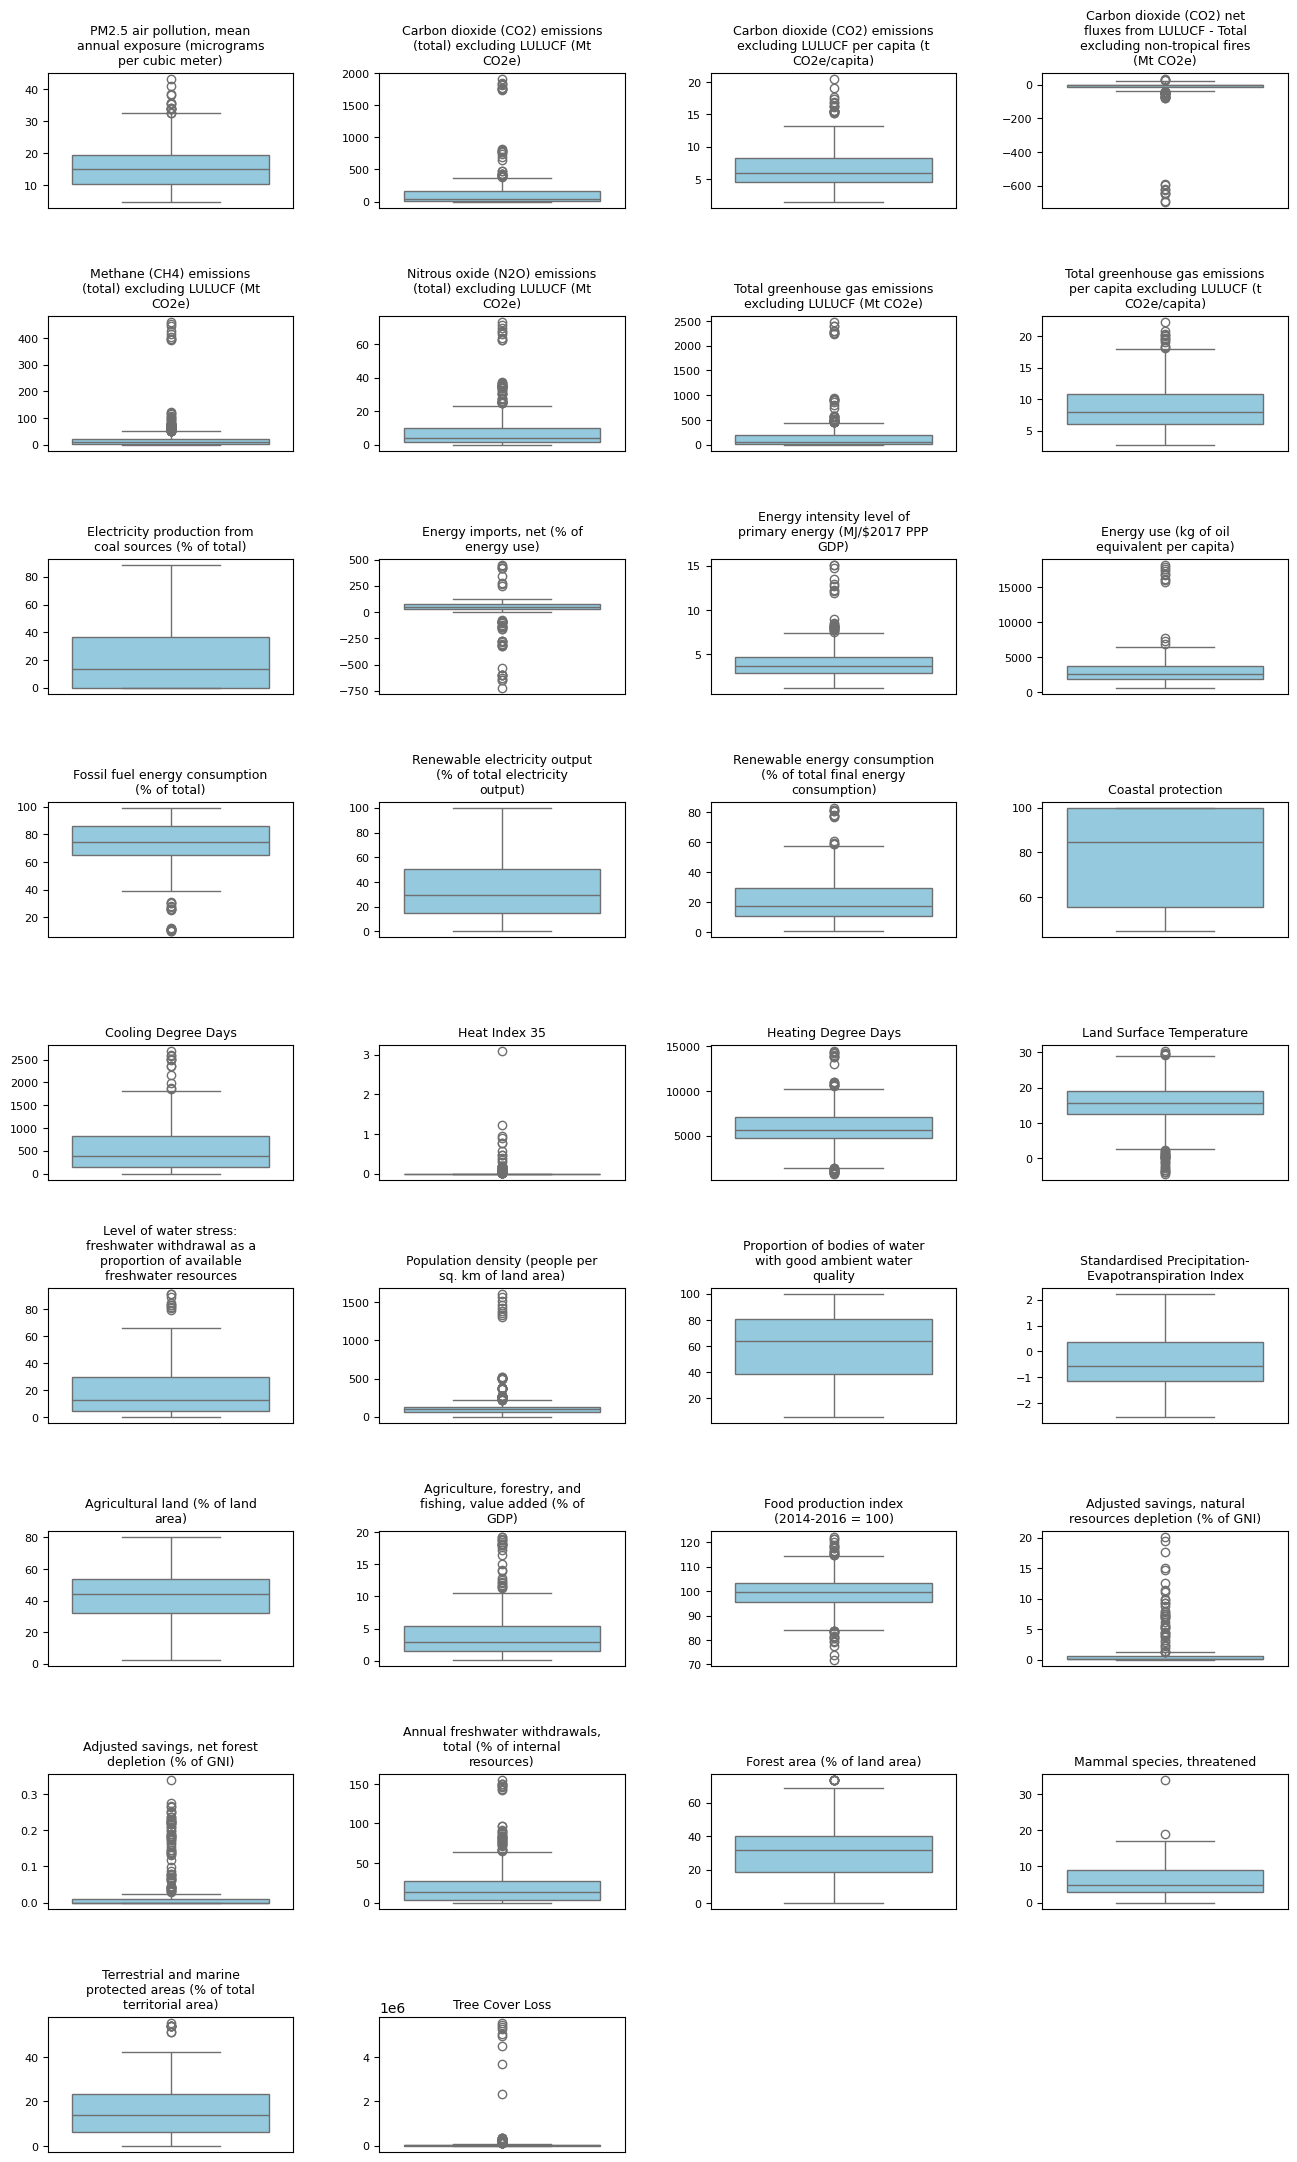

In [26]:
boxplots(env_europe)

### Skewness and Percentage of Outliers

In [27]:
so_env = skewness_outliers(env_europe)
so_env

,Indicator,Skewness,Outlier %
0,"Adjusted savings, net forest depletion (% of GNI)",2.623205,16.751269
1,Methane (CH4) emissions (total) excluding LULU...,5.092070,16.279070
2,Carbon dioxide (CO2) net fluxes from LULUCF - ...,6.139170,14.074074
3,Heat Index 35,11.467994,12.839506
4,Population density (people per sq. km of land ...,4.899574,12.839506
5,Nitrous oxide (N2O) emissions (total) excludin...,2.532728,11.627907
6,"Energy imports, net (% of energy use)",2.862036,11.568123
7,"Adjusted savings, natural resources depletion ...",4.258084,10.913706
8,Total greenhouse gas emissions excluding LULUC...,4.314458,10.852713
9,Tree Cover Loss,6.634653,10.256410


## <span style="color:#e0bda8">8.2. Social Pillar </span>

### Descriptive Statistics

In [28]:
soc_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
Access to clean fuels and technologies for cooking (% of population),396.0,95.11,11.83,40.80,97.57,100.00,100.00,100.00
Access to electricity (% of population),405.0,99.83,0.67,94.70,100.00,100.00,100.00,100.00
People using safely managed drinking water services (% of population),387.0,91.74,9.81,66.14,87.83,96.14,99.26,100.00
People using safely managed sanitation services (% of population),375.0,75.59,23.19,10.83,68.55,82.49,90.79,99.81
"Fertility rate, total (births per woman)",405.0,1.62,0.28,1.13,1.43,1.57,1.74,3.13
"Life expectancy at birth, total (years)",405.0,78.25,3.81,69.91,75.19,78.24,81.56,83.90
Population ages 65 and above (% of total population),405.0,16.59,3.84,5.68,14.15,17.71,19.28,23.38
"Government expenditure on education, total (% of government expenditure)",372.0,11.71,2.59,2.20,9.74,11.25,13.32,20.84
"Literacy rate, adult total (% of people ages 15 and above)",39.0,98.47,1.61,95.00,97.80,99.00,100.00,100.00


### Boxplots

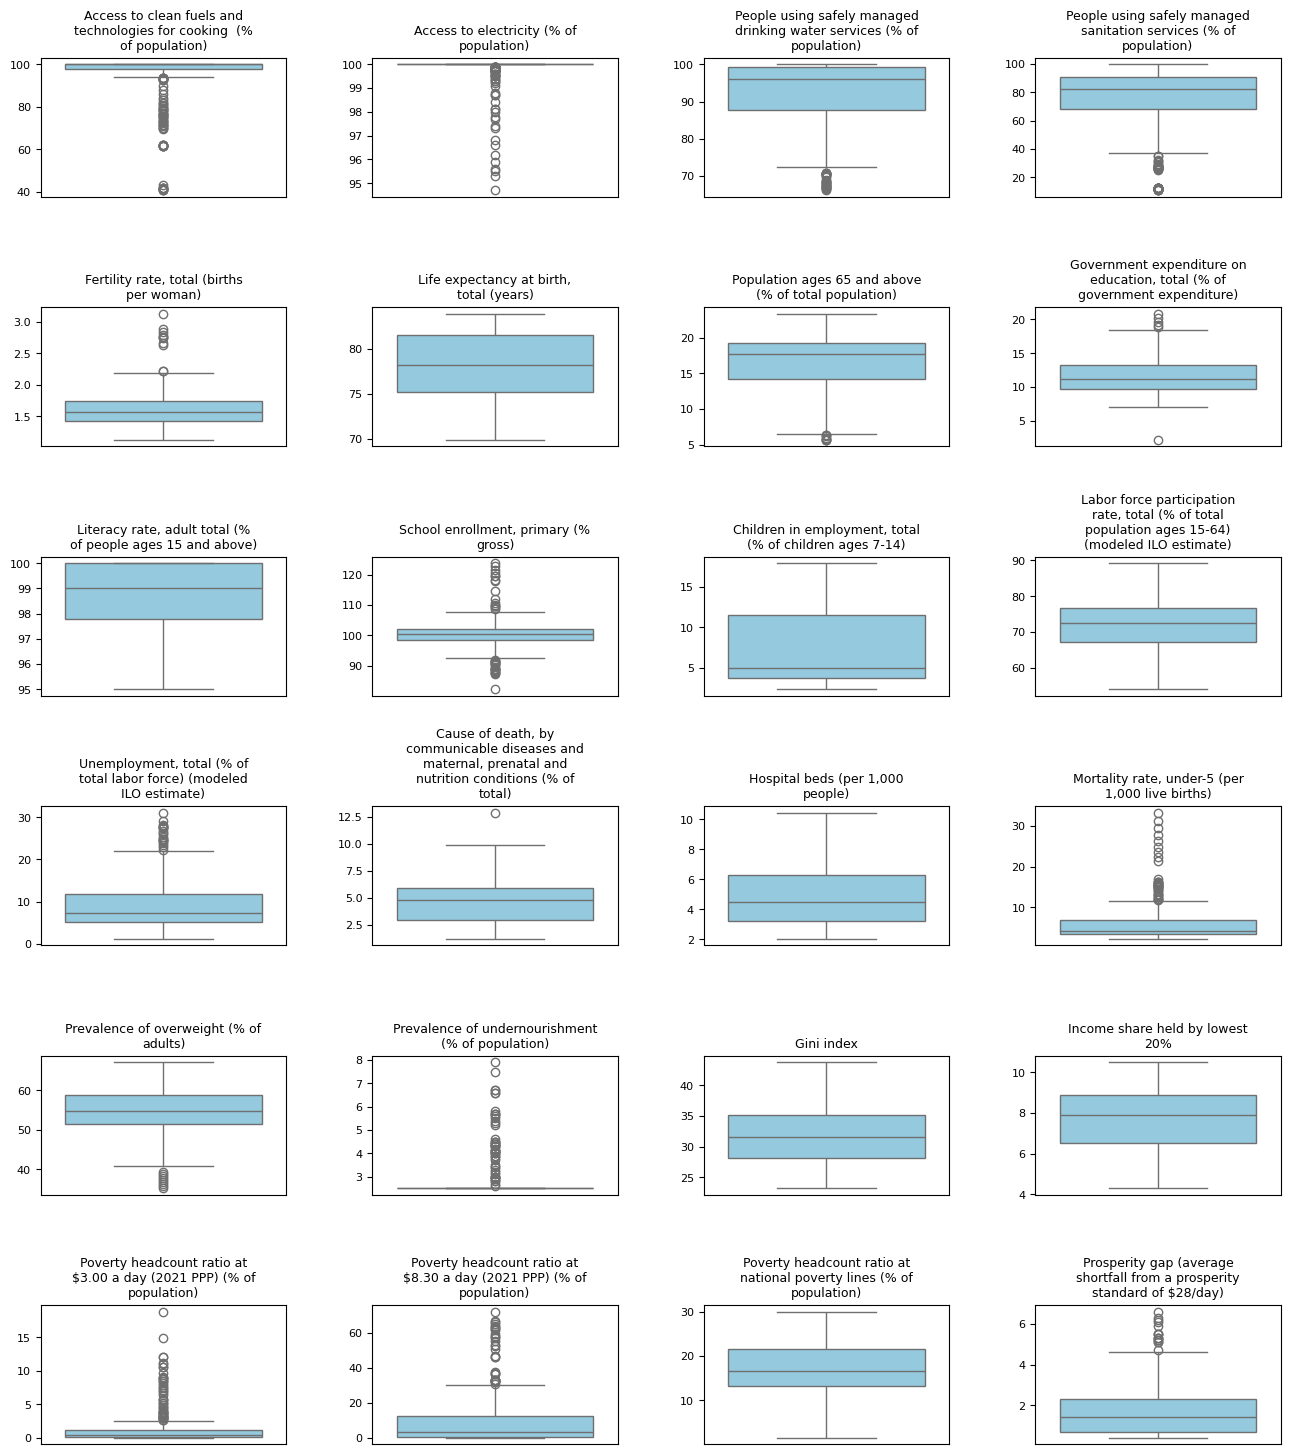

In [29]:
boxplots(soc_europe)

### Skewness and Percentage of Outliers

In [30]:
so_soc = skewness_outliers(soc_europe)
so_soc

,Indicator,Skewness,Outlier %
0,Access to clean fuels and technologies for coo...,2.956749,15.909091
1,Access to electricity (% of population),5.226753,15.802469
2,Prevalence of undernourishment (% of population),3.727208,13.333333
3,Poverty headcount ratio at $3.00 a day (2021 P...,3.359641,13.089005
4,People using safely managed sanitation service...,1.377882,10.133333
5,"School enrollment, primary (% gross)",0.933802,9.390863
6,"Mortality rate, under-5 (per 1,000 live births)",2.614597,9.135802
7,Poverty headcount ratio at $8.30 a day (2021 P...,2.236054,8.638743
8,People using safely managed drinking water ser...,1.212493,7.493540
9,"Unemployment, total (% of total labor force) (...",1.317233,5.185185


## <span style="color:#e0bda8">8.3. Governance Pillar </span>

### Descriptive Statistics

In [31]:
gov_europe.describe(include="all").round(2).T

,count,mean,std,min,25%,50%,75%,max
Indicator name,,,,,,,,
GDP (annual % growth),405.0,1.72,3.63,-15.31,0.47,2.12,3.57,24.62
Individuals using the Internet (% of population),405.0,75.98,14.11,34.70,67.90,77.60,87.00,99.50
Proportion of seats held by women in national parliaments (%),405.0,26.50,9.81,8.70,18.67,25.22,34.78,47.62
Ratio of female to male labor force participation rate (%) (modeled ILO estimate),405.0,79.50,9.06,41.51,75.32,81.18,84.24,101.67
"School enrollment, primary and secondary (gross), gender parity index (GPI)",365.0,1.00,0.03,0.96,0.98,1.00,1.01,1.10
Unmet need for contraception (% of married women ages 15-49),21.0,12.86,5.54,4.90,9.00,11.60,15.47,23.70
Government Effectiveness: Estimate,405.0,0.73,0.79,-1.08,0.00,0.83,1.44,2.21
Regulatory Quality: Estimate,405.0,0.82,0.73,-1.17,0.26,0.91,1.45,2.04
Economic and Social Rights Performance Score,405.0,4.53,0.51,2.91,4.46,4.72,4.87,4.99


### Boxplots

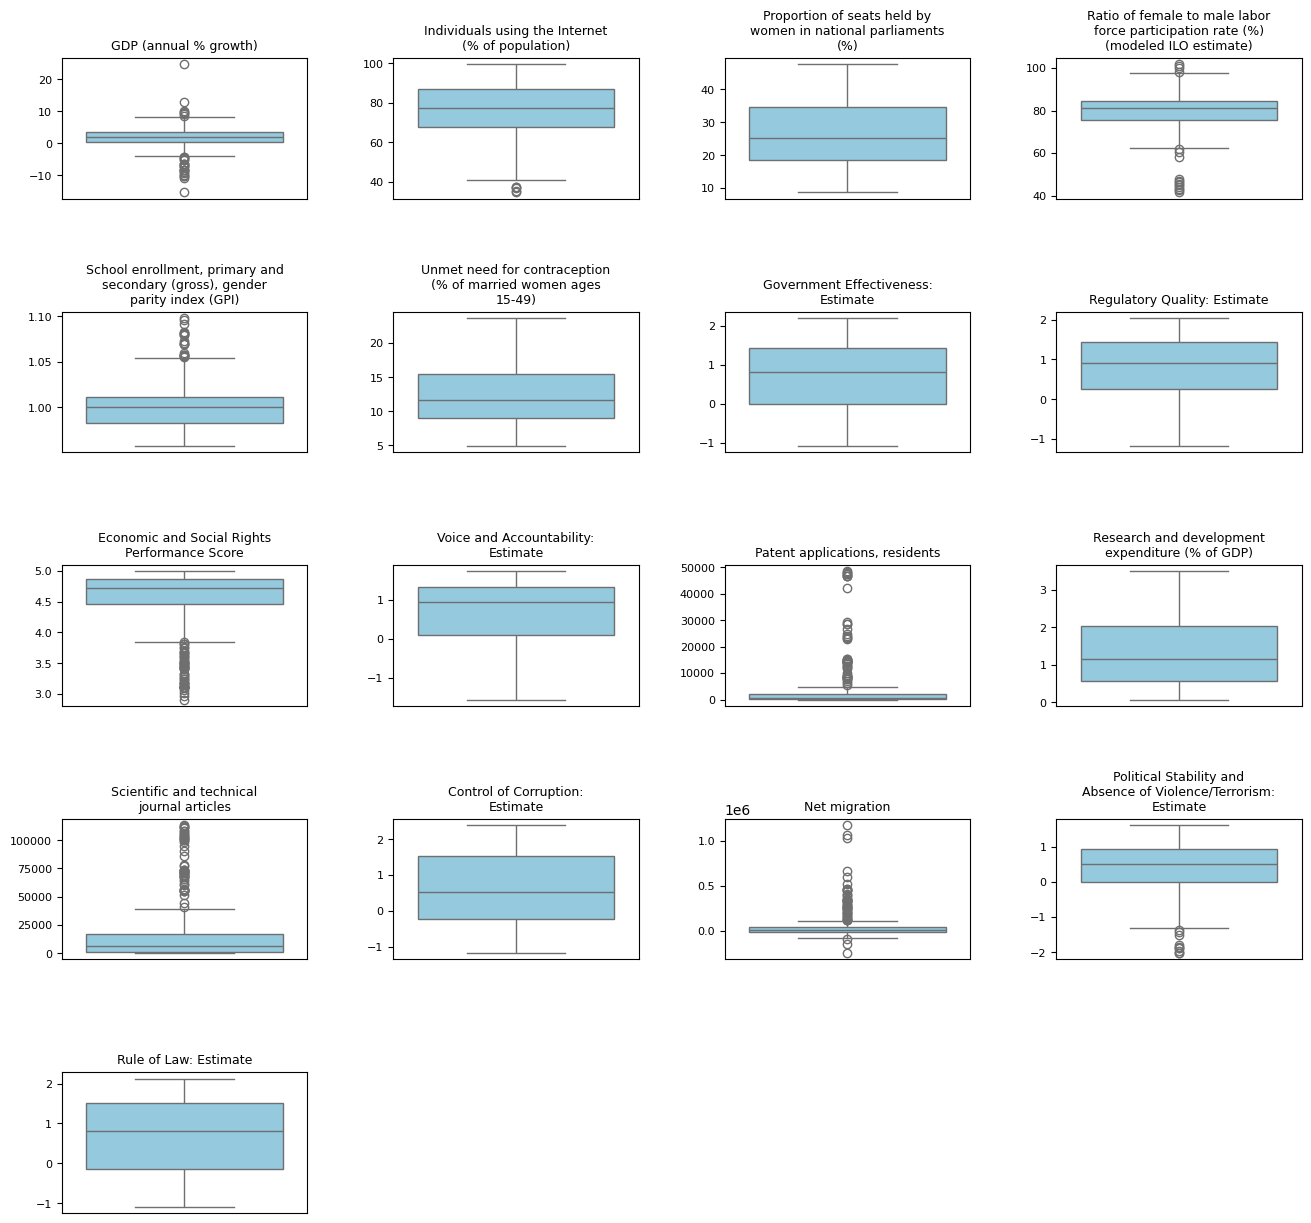

In [32]:
boxplots(gov_europe)

### Percentage of Outliers

In [33]:
so_gov = skewness_outliers(gov_europe)
so_gov

,Indicator,Skewness,Outlier %
0,"Patent applications, residents",3.895390,13.157895
1,Scientific and technical journal articles,2.095190,13.086420
2,Economic and Social Rights Performance Score,1.594943,13.086420
3,Net migration,4.322887,11.851852
4,GDP (annual % growth),0.363141,7.160494
5,"School enrollment, primary and secondary (gros...",1.203097,5.753425
6,Ratio of female to male labor force participat...,1.290928,3.950617
7,Political Stability and Absence of Violence/Te...,0.957328,2.469136
8,Individuals using the Internet (% of population),0.523500,1.234568
9,Regulatory Quality: Estimate,0.394643,0.000000


# <span style="color:#e0bda8">9. Bivariate Analysis</span>

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap


def correlation_heatmap(criteria, text_color = '#1e1e1e', background_color = 'white'):
    for c in criteria:
        cor_spearman = c.corr(method="spearman")
        mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

        labels = cor_spearman.columns.tolist()

        masked_labels = []
        for i, label in enumerate(labels):
            if all(mask[i, :i+1]):  
                masked_labels.append("")
            else:
                masked_labels.append(label)

        wrapped_labels = ["\n".join(textwrap.wrap(l, width=20)) for l in labels]
        wrapped_labels_2 = [textwrap.fill(l, width=10) for l in labels]

        fig, ax = plt.subplots(figsize=(12, 10))
        fig.patch.set_facecolor(background_color)
        ax.set_facecolor(background_color)

        sns.heatmap(
            cor_spearman,
            mask=mask,
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            square=True,
            cbar_kws={"shrink": 0.8},
            ax=ax,
            annot_kws={
                "color": "#000000",  
                "fontweight": "bold",
                "fontsize": 12
            }
        )
    
        ax.set_yticklabels(wrapped_labels, rotation=0, ha='right', color=text_color)
        ax.set_xticklabels(wrapped_labels_2, rotation=0, ha='center', color=text_color)
        ax.set_xlabel("Indicator Name", color=text_color, fontsize=14)  
        ax.set_ylabel("Indicator Name", color=text_color, fontsize=14)  

  
        ax.tick_params(colors=text_color)
        ax.set_title("Spearman Correlation Heatmap", fontsize=16, color=text_color)

        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_tick_params(color=text_color)
        plt.setp(cbar.ax.get_yticklabels(), color=text_color)
        cbar.set_label('Correlation', color=text_color)

        plt.show()



In [35]:
emissions_polution = ['PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)', 
                      'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
                      'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
                      'Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)',
                      'Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)',
                      'Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)',
                      'Total greenhouse gas emissions excluding LULUCF (Mt CO2e)',
                      'Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita)']

energy_security = ['Electricity production from coal sources (% of total)',
                   'Energy imports, net (% of energy use)',
                   'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
                   'Energy use (kg of oil equivalent per capita)',
                   'Fossil fuel energy consumption (% of total)',
                   'Renewable electricity output (% of total electricity output)',
                   'Renewable energy consumption (% of total final energy consumption)']

climate_resilience = ['Coastal protection',  
                      'Cooling Degree Days',
                      'Heat Index 35',
                      'Heating Degree Days',
                      'Land Surface Temperature',
                      'Level of water stress: freshwater withdrawal as a proportion of available freshwater resources',
                      'Population density (people per sq. km of land area)',
                      'Proportion of bodies of water with good ambient water quality', 
                      'Standardised Precipitation-Evapotranspiration Index']

food_security = ['Agricultural land (% of land area)',
                 'Agriculture, forestry, and fishing, value added (% of GDP)',
                 'Food production index (2014-2016 = 100)']

endowment_management = ['Adjusted savings, natural resources depletion (% of GNI)',
                        'Adjusted savings, net forest depletion (% of GNI)',
                        'Annual freshwater withdrawals, total (% of internal resources)',
                        'Forest area (% of land area)',
                        'Mammal species, threatened',  
                        'Terrestrial and marine protected areas (% of total territorial area)',   
                        'Tree Cover Loss']

emissions_polution_europe = df_europe[emissions_polution] 
energy_security_europe = df_europe[energy_security] 
climate_resilience_europe = df_europe[climate_resilience]
food_security_europe = df_europe[food_security]
endowment_management_europe = df_europe[endowment_management]

In [36]:
access_services = ['Access to clean fuels and technologies for cooking  (% of population)',
                   'Access to electricity (% of population)',
                   'People using safely managed drinking water services (% of population)',
                   'People using safely managed sanitation services (% of population)']


demography = ['Fertility rate, total (births per woman)',
              'Life expectancy at birth, total (years)',
              'Population ages 65 and above (% of total population)']

education_skills = ['Government expenditure on education, total (% of government expenditure)',
                    'Literacy rate, adult total (% of people ages 15 and above)', # 1
                    'School enrollment, primary (% gross)']

employment = ['Children in employment, total (% of children ages 7-14)', #1
              'Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)',
              'Unemployment, total (% of total labor force) (modeled ILO estimate)']

health_nutrition = ['Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)', 
                    'Hospital beds (per 1,000 people)',
                    'Mortality rate, under-5 (per 1,000 live births)',
                    'Prevalence of overweight (% of adults)',
                    'Prevalence of undernourishment (% of population)']

poverty_inequality = ['Gini index',
                      'Income share held by lowest 20%',
                      'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
                      'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)',
                      'Poverty headcount ratio at national poverty lines (% of population)', 
                      'Prosperity gap (average shortfall from a prosperity standard of $28/day)']

access_services_europe = df_europe[access_services] 
demography_europe = df_europe[demography] 
education_skills_europe = df_europe[education_skills]
employment_europe = df_europe[employment]
health_nutrition_europe = df_europe[health_nutrition]
poverty_inequality_europe = df_europe[poverty_inequality]

In [37]:
economic_environment = ['GDP (annual % growth)',
                        'Individuals using the Internet (% of population)']

gender = ['Proportion of seats held by women in national parliaments (%)',
          'Ratio of female to male labor force participation rate (%) (modeled ILO estimate)',
          'School enrollment, primary and secondary (gross), gender parity index (GPI)',
          'Unmet need for contraception (% of married women ages 15-49)'] #1

gov_effectiveness = ['Government Effectiveness: Estimate',
                     'Regulatory Quality: Estimate']

human_rights = ['Economic and Social Rights Performance Score',
                'Voice and Accountability: Estimate']

innovation = ['Patent applications, residents',
              'Research and development expenditure (% of GDP)',
              'Scientific and technical journal articles']

stability_rule_law = ['Control of Corruption: Estimate',
                      'Net migration',
                      'Political Stability and Absence of Violence/Terrorism: Estimate',
                      'Rule of Law: Estimate']

economic_environment_europe = df_europe[economic_environment] 
gender_europe = df_europe[gender] 
gov_effectiveness_europe = df_europe[gov_effectiveness]
human_rights_europe = df_europe[human_rights]
innovation_europe = df_europe[innovation]
stability_rule_law_europe = df_europe[stability_rule_law]

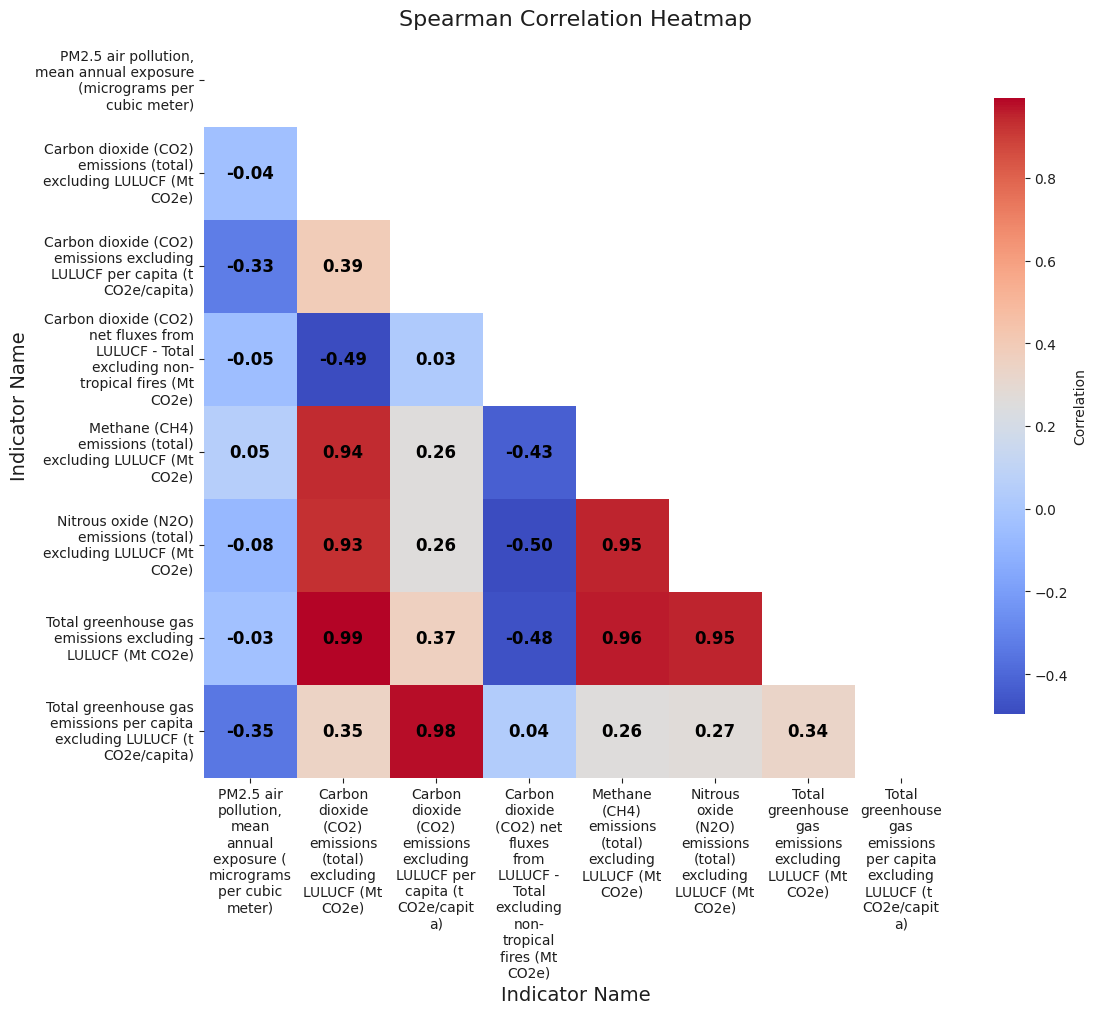

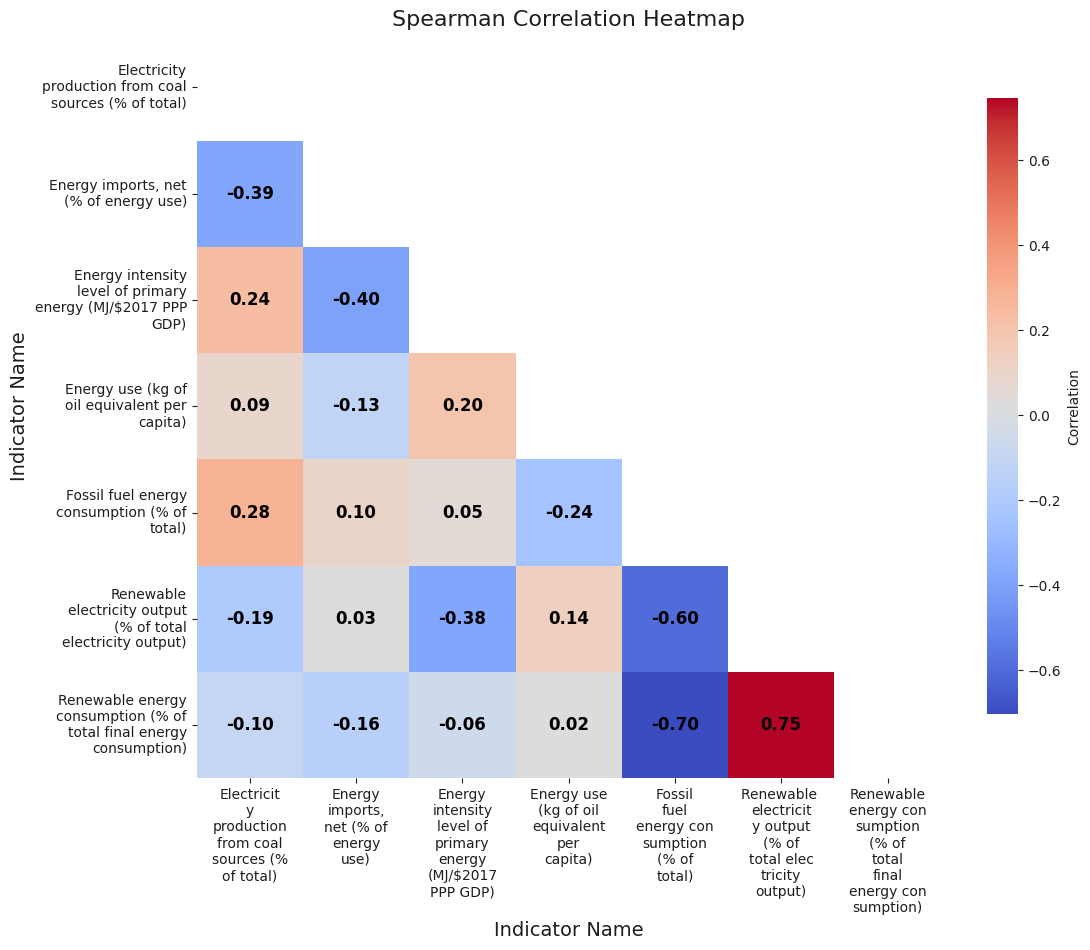

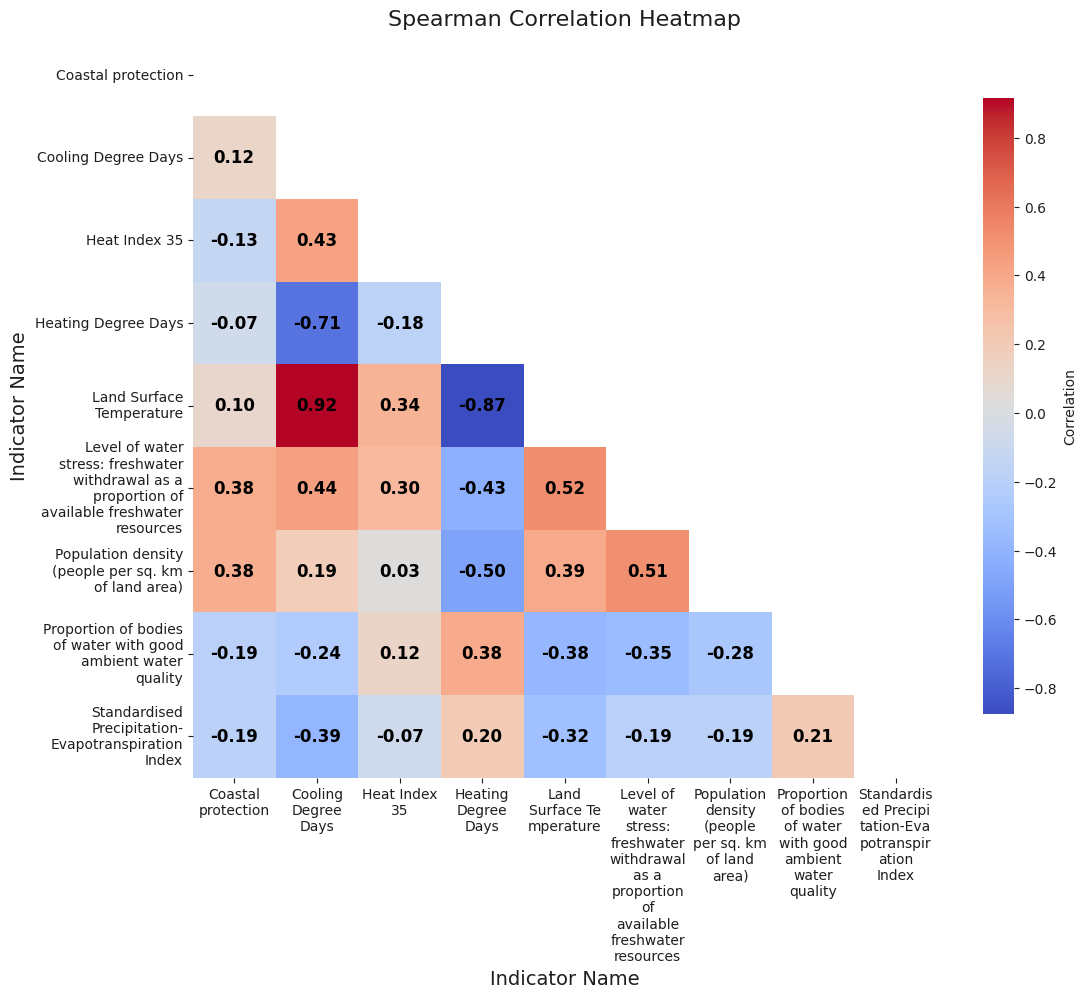

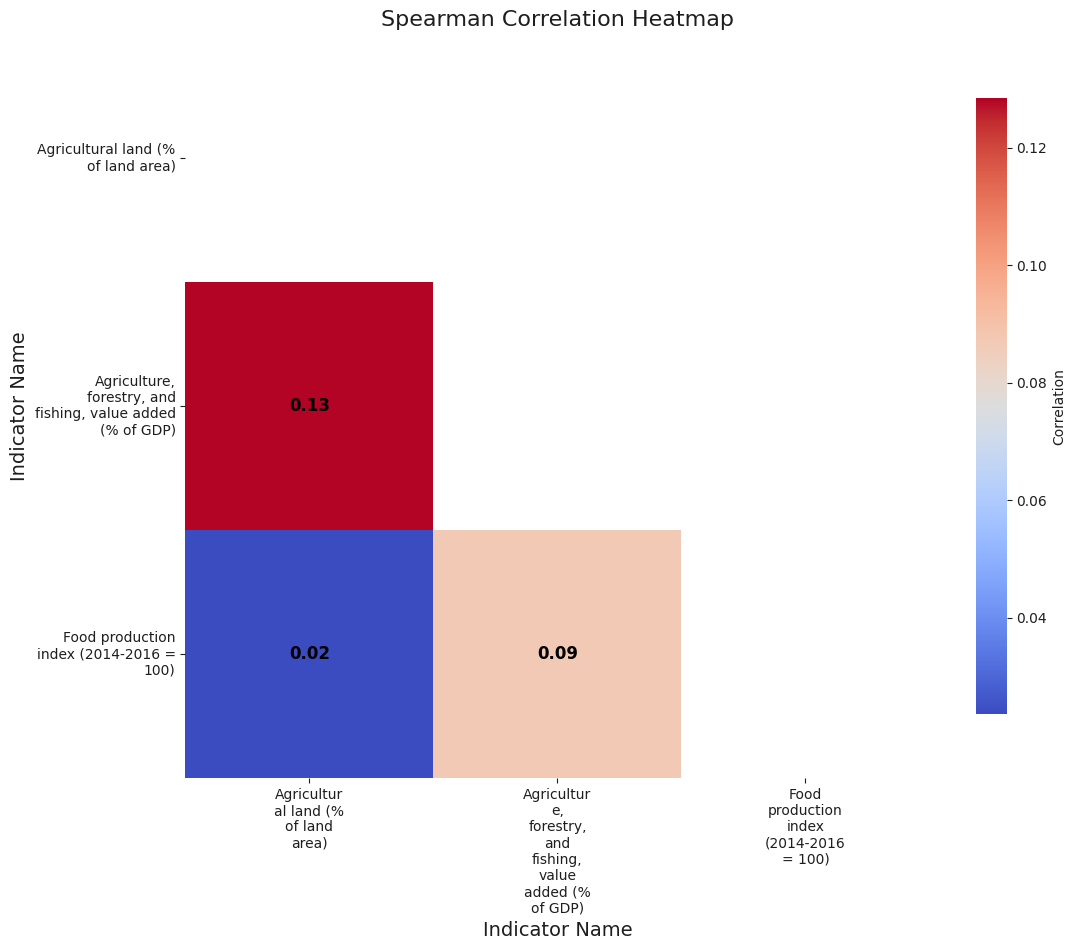

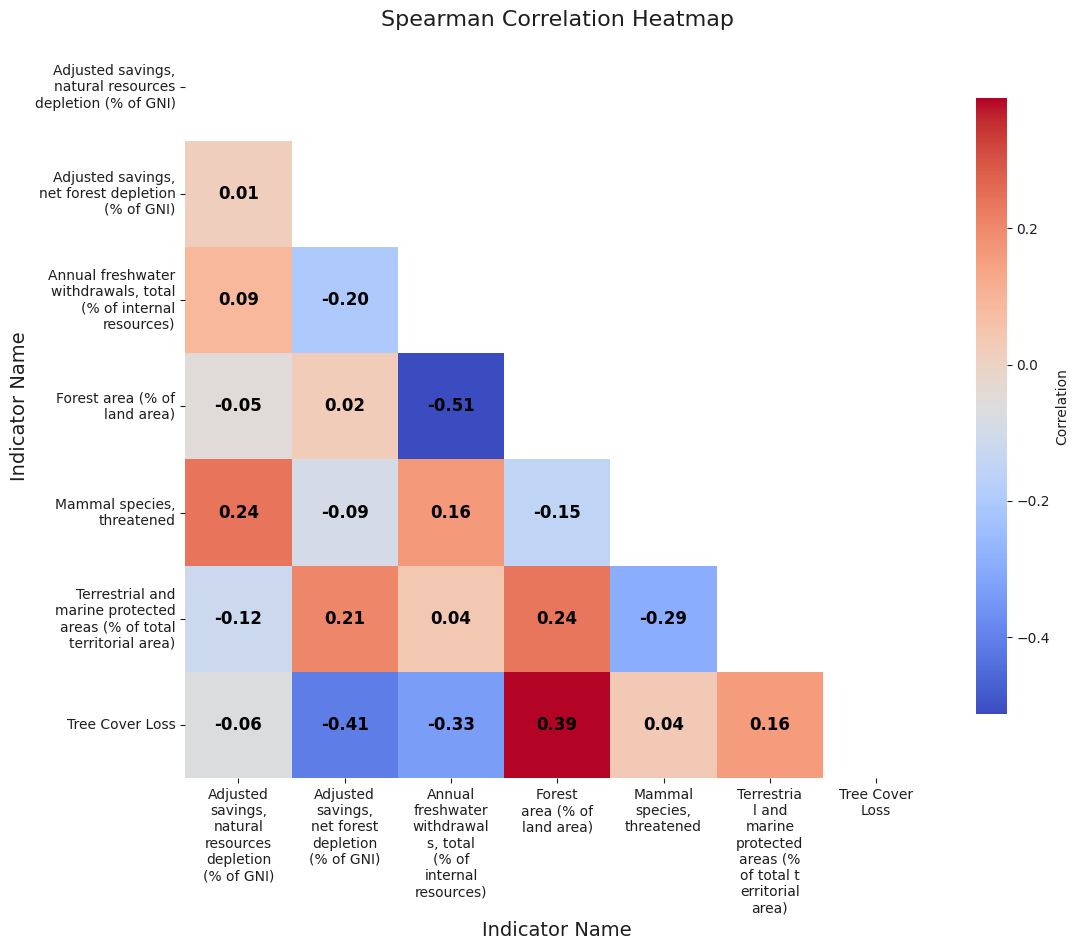

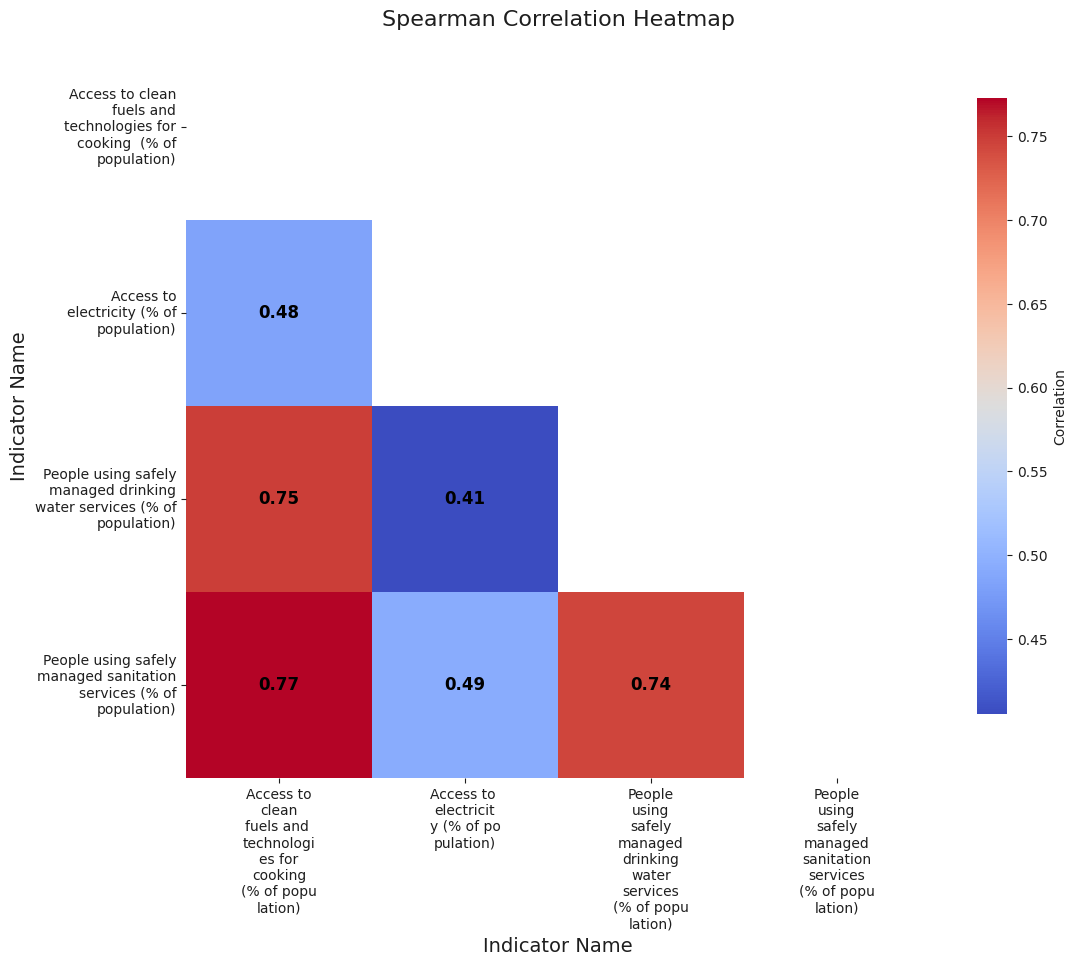

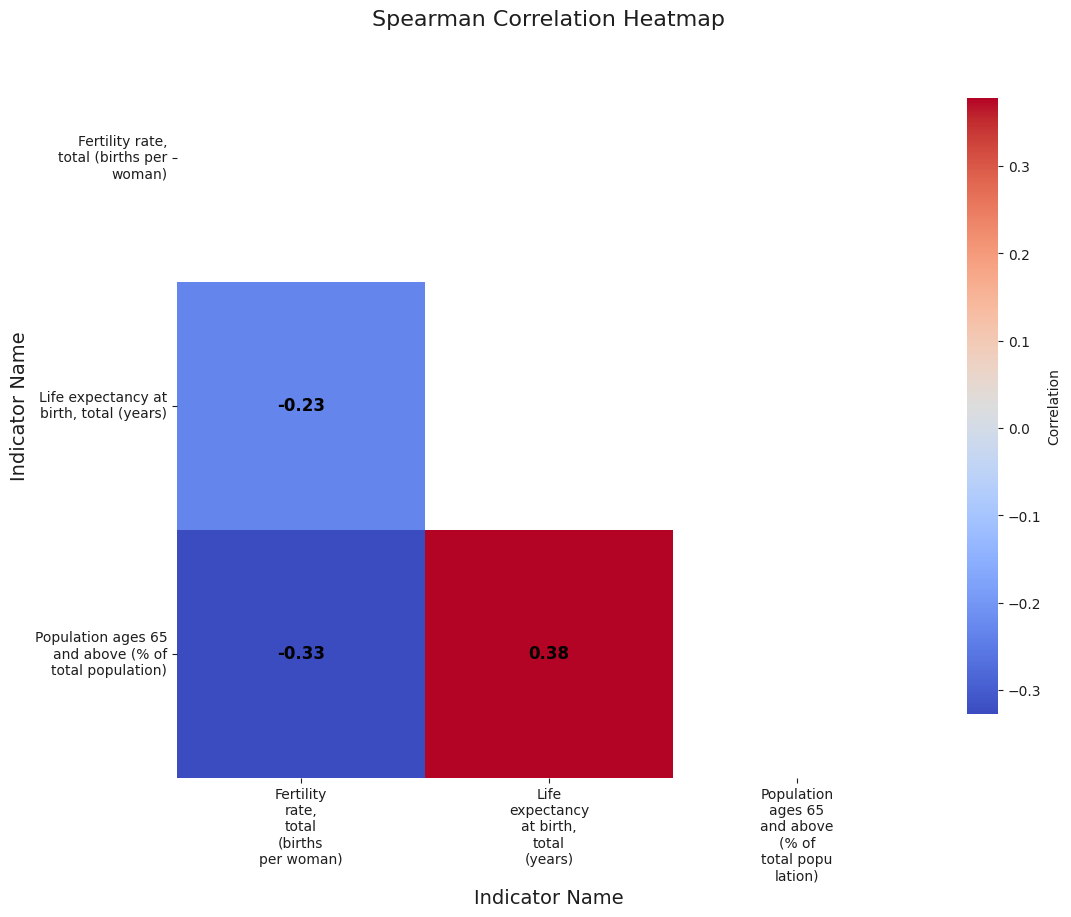

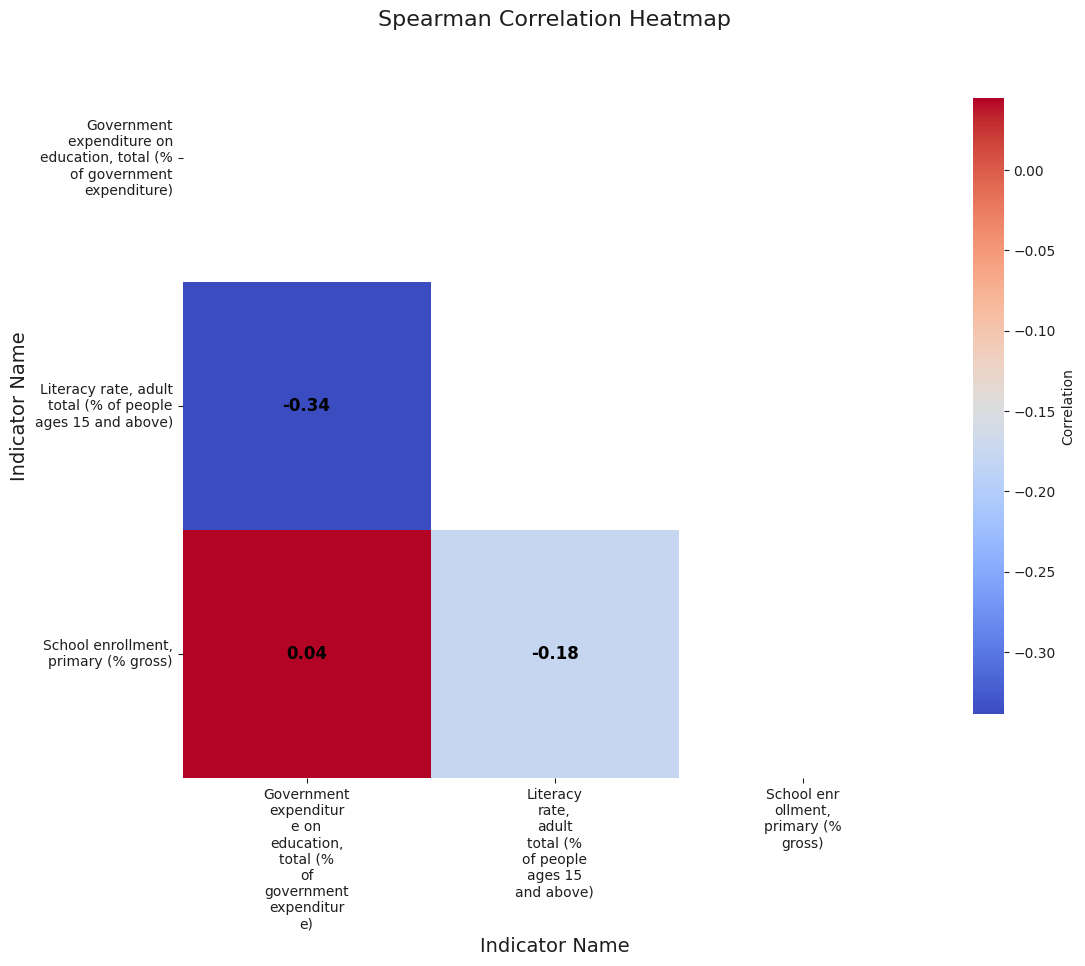

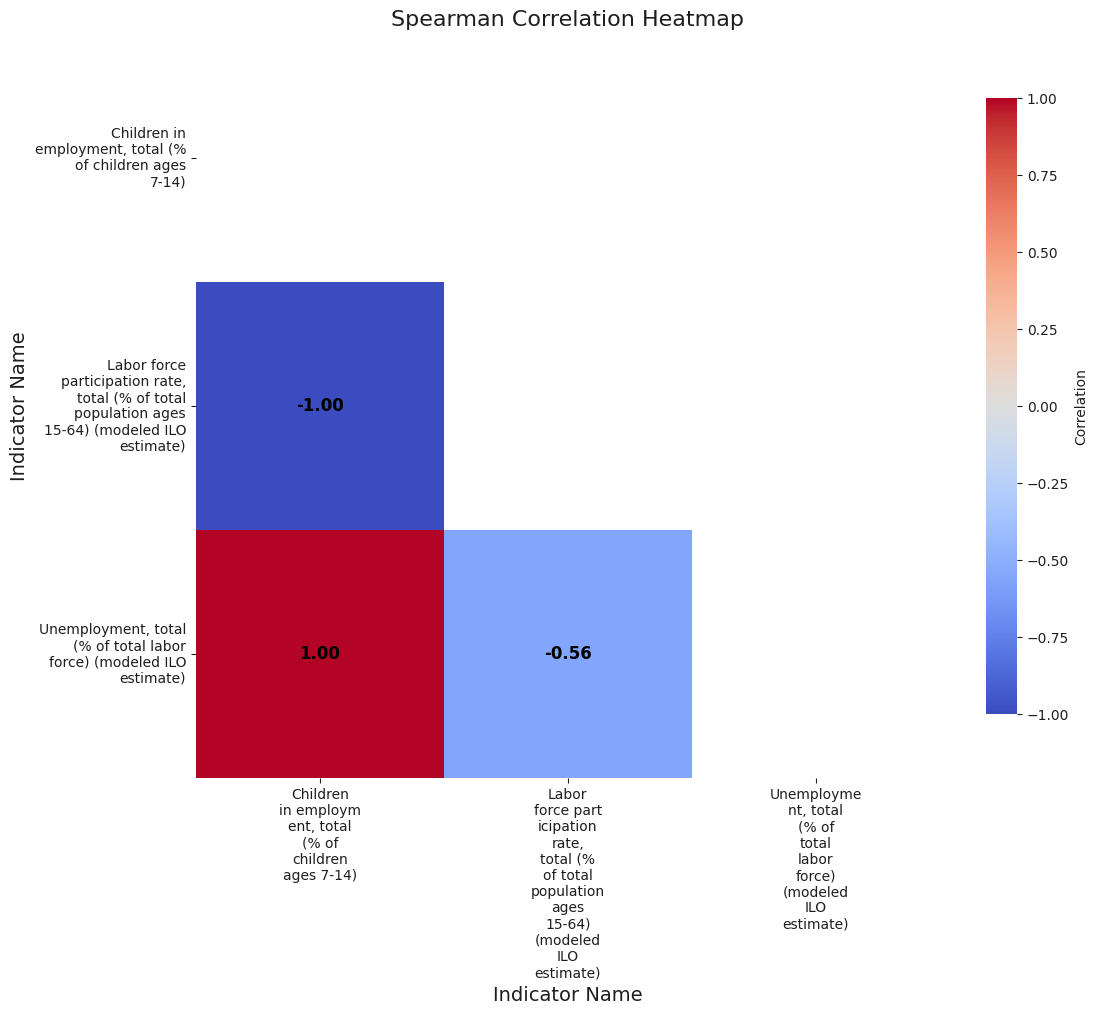

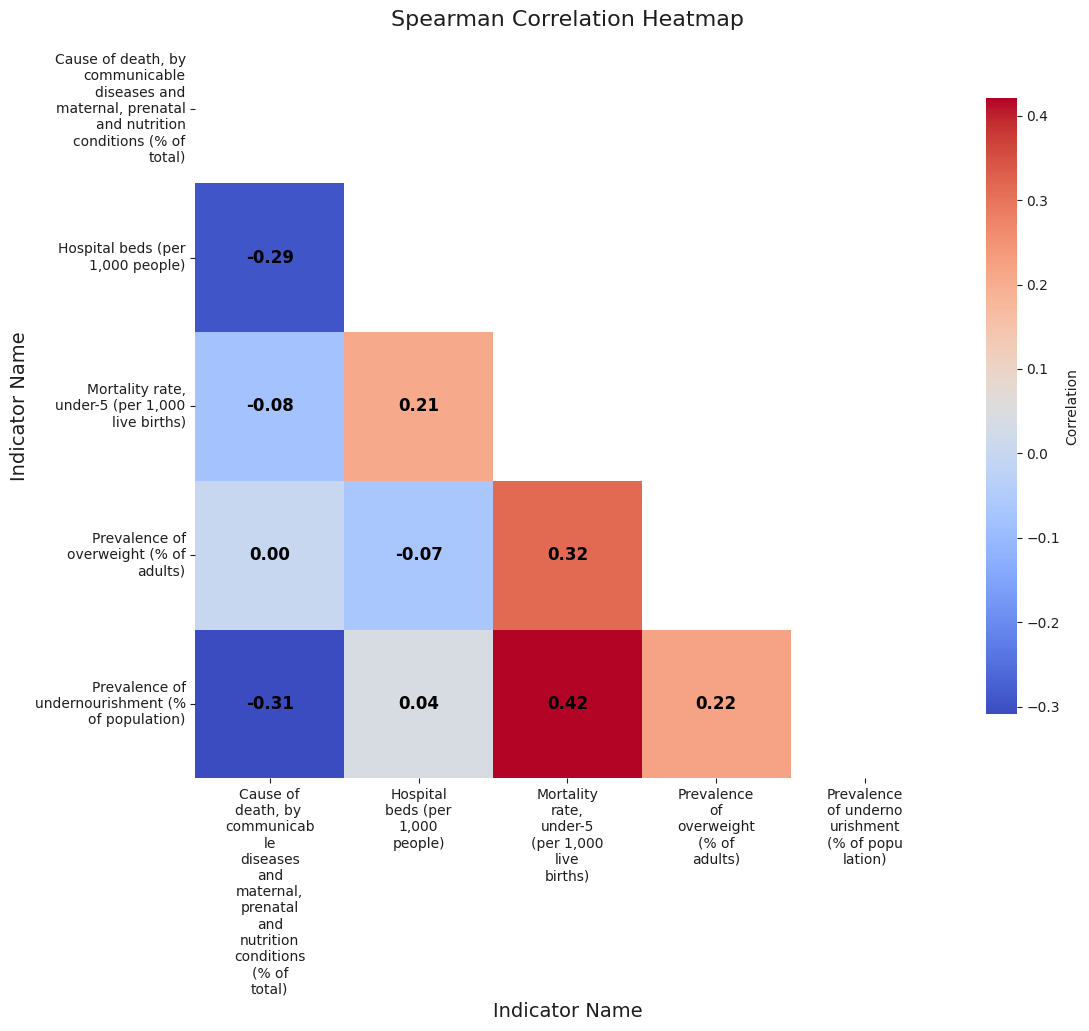

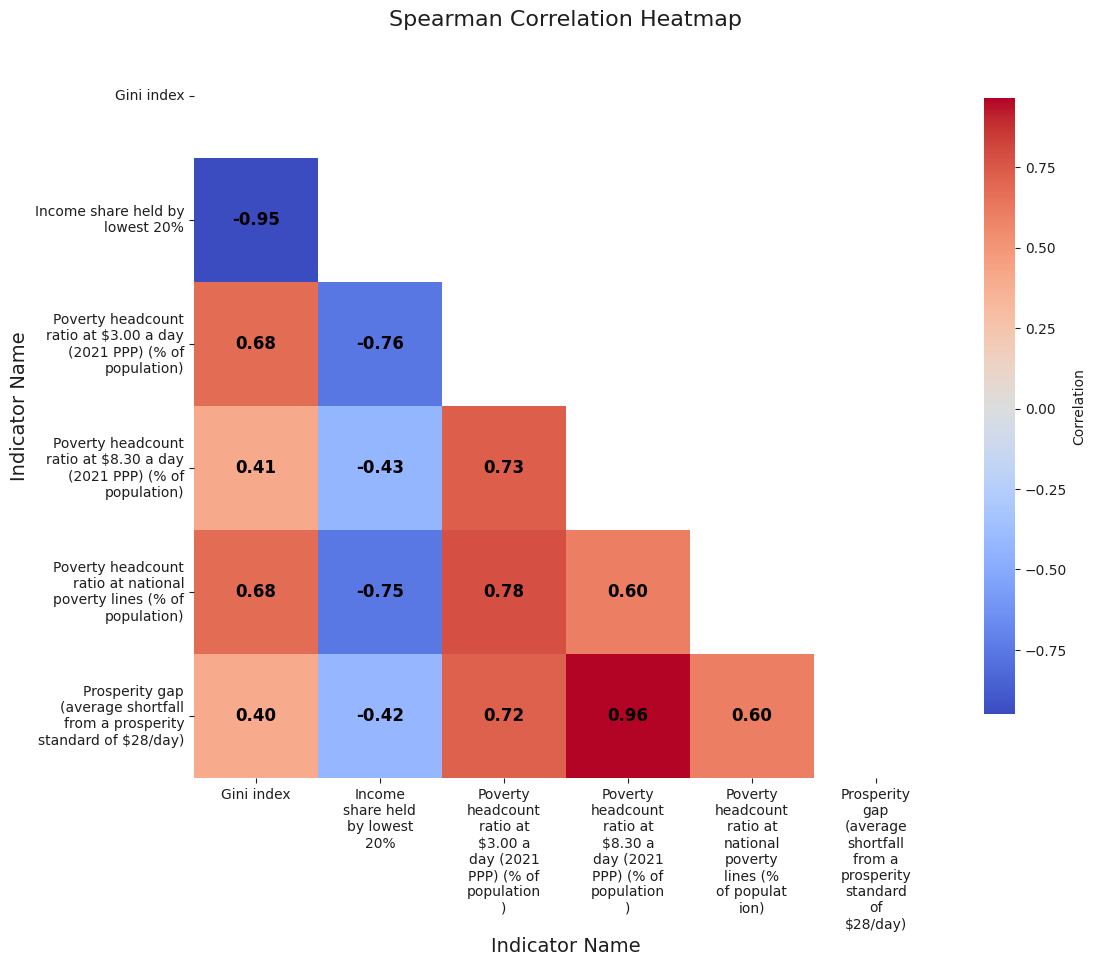

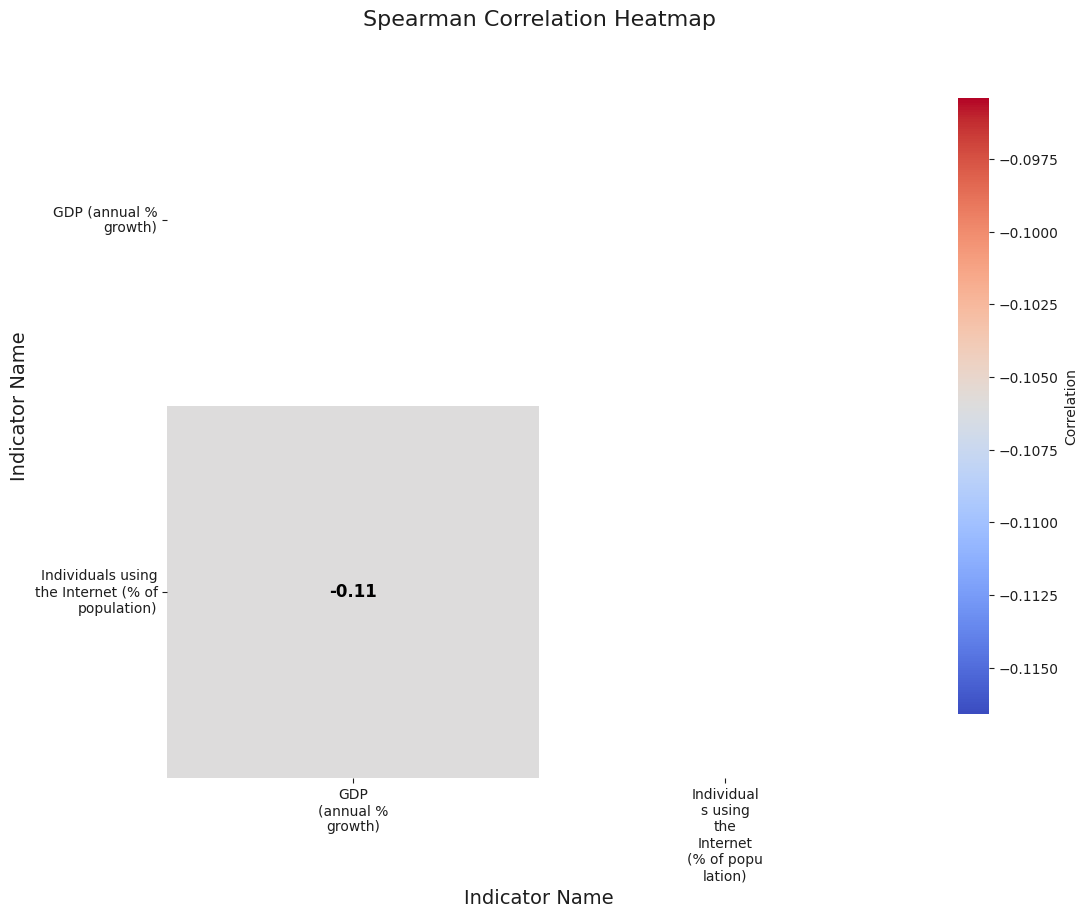

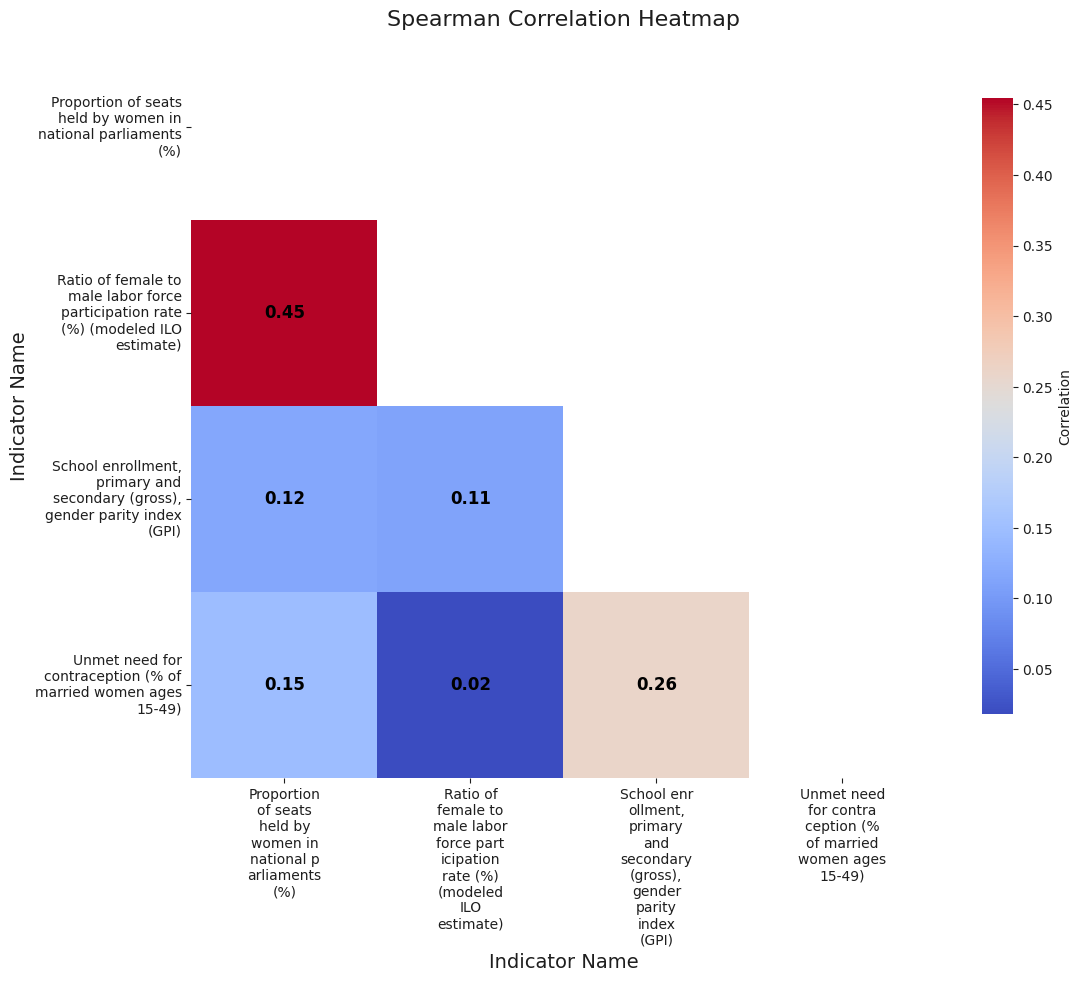

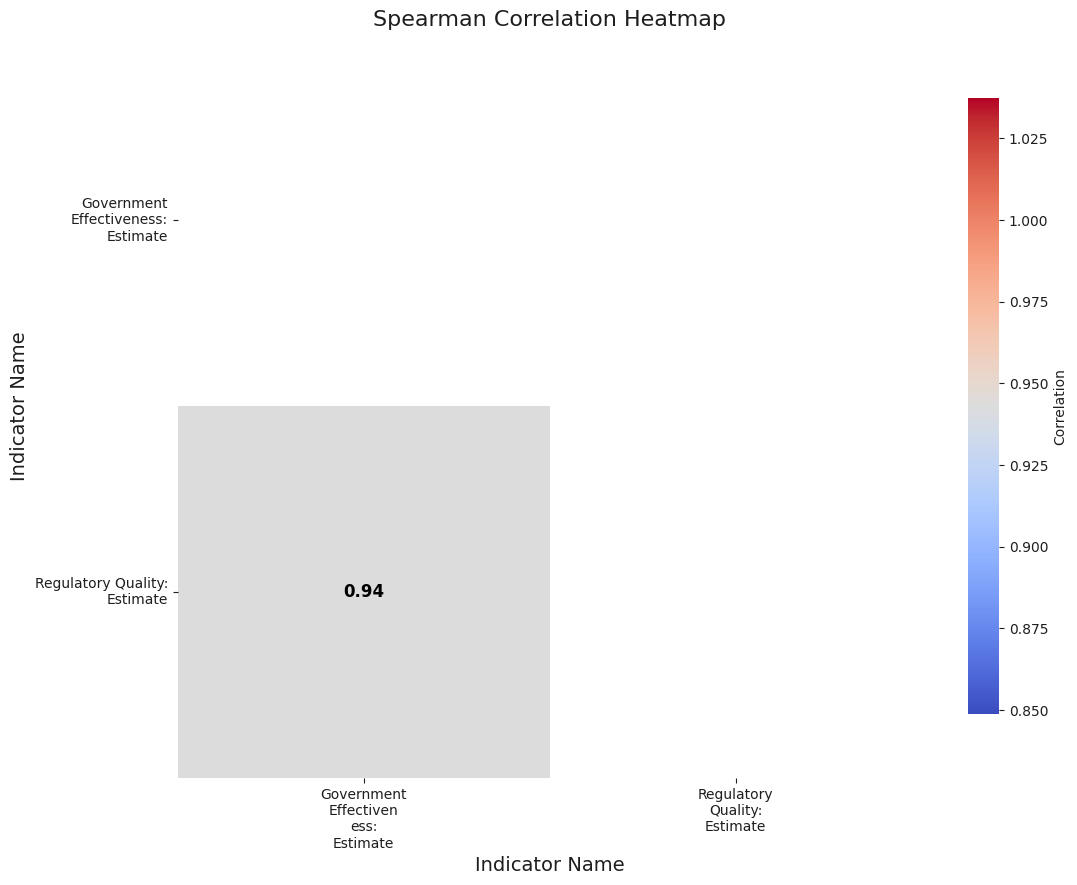

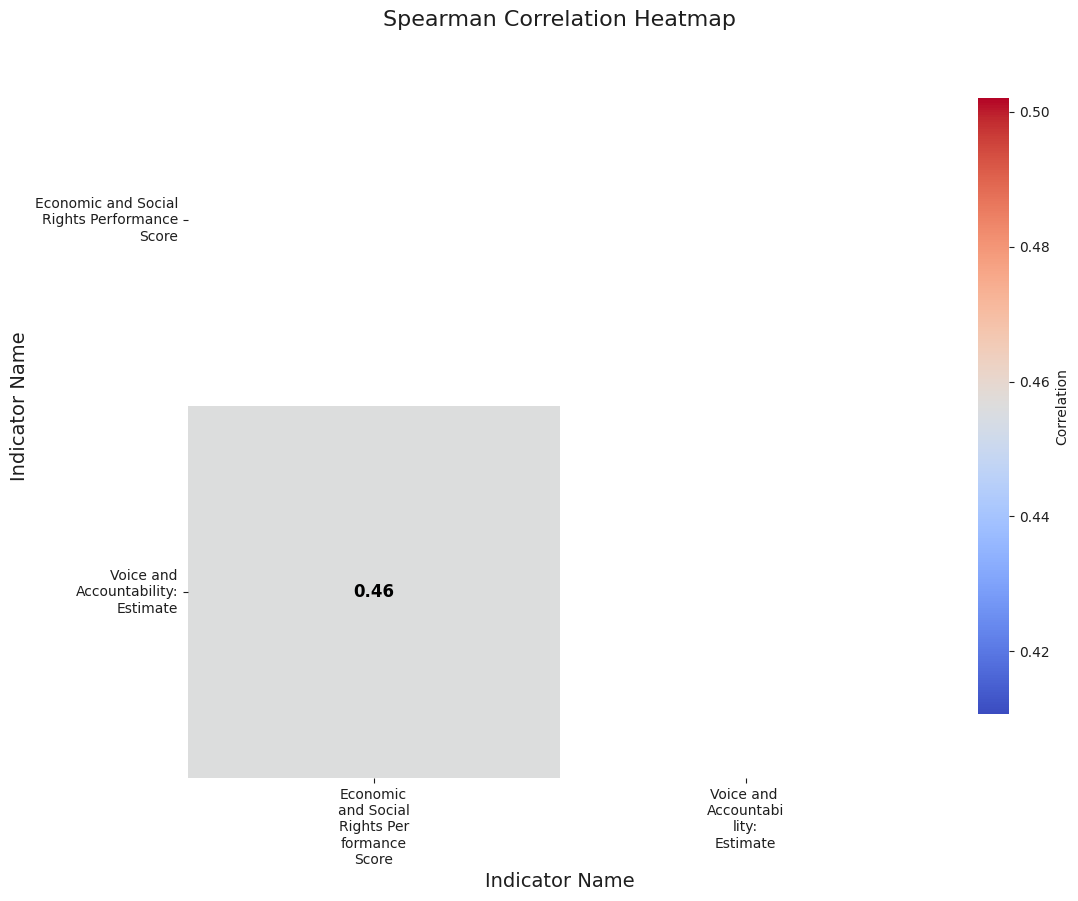

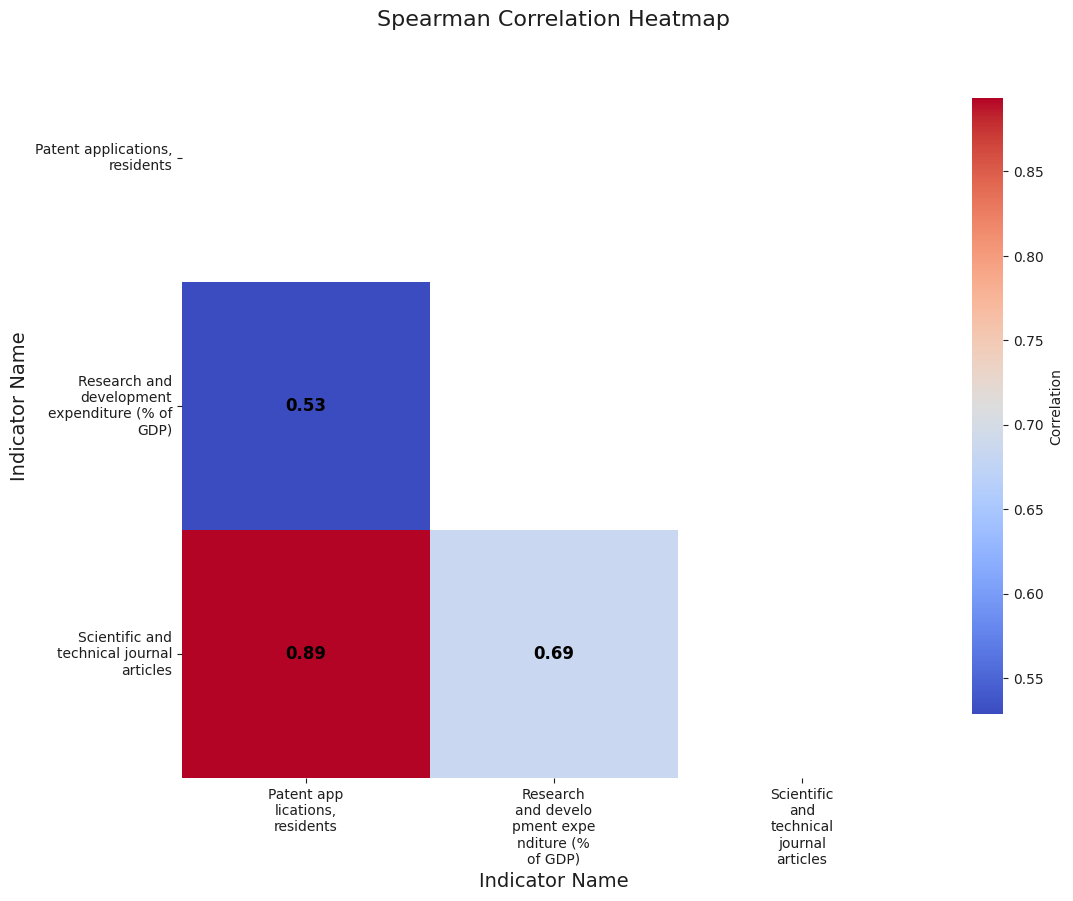

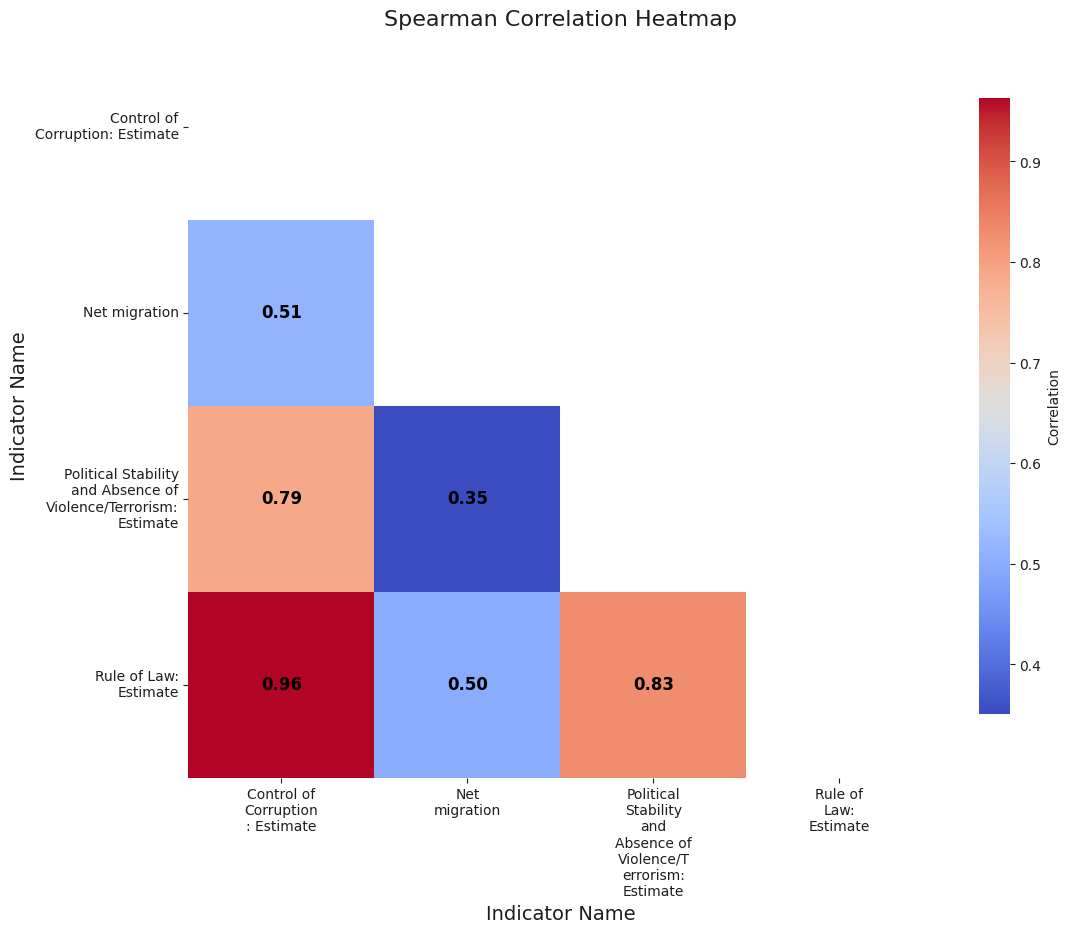

In [38]:
criteria = [emissions_polution_europe, energy_security_europe, climate_resilience_europe, food_security_europe, 
            endowment_management_europe, access_services_europe, demography_europe, education_skills_europe, 
            employment_europe, health_nutrition_europe, poverty_inequality_europe, economic_environment_europe, 
            gender_europe, gov_effectiveness_europe, human_rights_europe, innovation_europe, stability_rule_law_europe]

correlation_heatmap(criteria)

### Highly Correlated Variables

- Total Greenhouse, CO2, CH4 and N2O emissions (all pairs go from 0.93-0.99); Total Greenhouse and CO2 per capita (0.98)       
- Land Surface Temperature and Cooling Degree Days (0.90); Land Surface Temperature and Heating Degree Days (-0.88)           
- Unemployment and Children in employment (0.94)                                                                              
- Prosperity Gap and Poverty Headcount Ratio at 8.30 (0.97); Income share held by the lowest 20% and Gini index  (-0.95)      
- Regulatory Quality and Government Effectiveness (0.94)                                                                      
- Scientific Journals and Patent Applications  (0.88)                                                                         
- Rule of Law and Control of Corruption (0.97)                                                                                 


# <span style="color:#e0bda8">10. Missing Value Imputation Test  </span>

### <span style="color:#e0bda8">10.0.  Variable Removal and Auxiliary Functions </span>

In [39]:
vars_removed = ['ISO3 code', 'Primary Forest Loss', 'Children in employment, total (% of children ages 7-14)', 
                'Unmet need for contraception (% of married women ages 15-49)', 'Mammal species, threatened',
                'Literacy rate, adult total (% of people ages 15 and above)', 'Proportion of bodies of water with good ambient water quality',
                'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)', 'Coastal protection'] 

vars_to_drop = [c for c in vars_removed if c in df_europe.columns]

df_europe = df_europe.drop(columns=vars_to_drop) 

env_indicators = [e for e in env_indicators if e in df_europe.columns]
df_env_europe = df_europe[env_indicators]

soc_indicators = [s for s in soc_indicators if s in df_europe.columns]
df_soc_europe = df_europe[soc_indicators]

gov_indicators = [g for g in gov_indicators if g in df_europe.columns]
df_gov_europe = df_europe[gov_indicators]

In [40]:
def imputation_evaluation(df_init, missing_fraction=0.1):
    # --- CONFIGURAÇÃO ---

    df = df_init.copy()

    # Resetar índice para trabalhar com colunas
    df = df.reset_index(drop=False)

    # Garantir que 'Year' é datetime
    df['Year'] = pd.to_datetime(df['Year'], format='%Y')

    # Selecionar apenas colunas numéricas
    numeric_cols = df.select_dtypes(include=np.number).columns

    # --- CRIAR MISSING ARTIFICIAL ---
    df_missing = df.copy()
    mask = pd.DataFrame(False, index=df.index, columns=numeric_cols)

    for col in numeric_cols:
        # % de valores a tornar missing em cada coluna
        n_missing = max(1, int(len(df) * missing_fraction))
    
        # Selecionar apenas índices com valores válidos
        valid_indices = df.index[df[col].notna()]
    
        # Ajustar caso n_missing seja maior ou igual aos valores válidos
        n_missing = min(n_missing, len(valid_indices)-1)
    
        missing_indices = np.random.choice(valid_indices, size=n_missing, replace=False)
        df_missing.loc[missing_indices, col] = np.nan
        mask.loc[missing_indices, col] = True  # salvar máscara para cálculo de erro

    numeric_cols = df_missing.select_dtypes(include=np.number).columns

    print(df_missing.columns)

    # --- IMPUTAÇÃO 1: MEDIANA ---
    df_median = df_missing.copy()
    for col in numeric_cols:
        df_median[col] = df_median[col].fillna(df_median[col].median())

    # --- IMPUTAÇÃO 2: INTERPOLAÇÃO TEMPORAL POR PAÍS ---
    df_interpolated = df_missing.copy()

    def interpolate_time(group):
        original_index = group.index
        group = group.set_index('Year')
        group[numeric_cols] = group[numeric_cols].interpolate(method='time')
        group[numeric_cols] = group[numeric_cols].ffill().bfill()
        group = group.reset_index()
        group.index = original_index
        return group

    df_interpolated = df_interpolated.groupby('Economy', group_keys=False).apply(interpolate_time, include_groups=False)

    
    # --- IMPUTAÇÃO 3: KNN ROBUST ---
    df_knn_robust = df_missing.copy()
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df_knn_robust[numeric_cols])
    knn = KNNImputer(n_neighbors=5)
    X_imputed_scaled = knn.fit_transform(X_scaled)
    df_knn_robust[numeric_cols] = scaler.inverse_transform(X_imputed_scaled)

    # --- IMPUTAÇÃO 4: KNN MINMAX ---
    df_knn_minmax = df_missing.copy()
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_knn_minmax[numeric_cols])
    X_imputed_scaled = knn.fit_transform(X_scaled)
    df_knn_minmax[numeric_cols] = scaler.inverse_transform(X_imputed_scaled)

    # --- IMPUTAÇÃO 5: KNN STANDARD ---
    df_knn_standard = df_missing.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_knn_standard[numeric_cols])
    X_imputed_scaled = knn.fit_transform(X_scaled)
    df_knn_standard[numeric_cols] = scaler.inverse_transform(X_imputed_scaled)

    # --- IMPUTAÇÃO 6: KNN SEM SCALING ---
    df_knn_no_scale = df_missing.copy()
    X_imputed_no_scaled = knn.fit_transform(df_knn_no_scale[numeric_cols])
    df_knn_no_scale[numeric_cols] = X_imputed_no_scaled

    # --- CALCULAR ERRO NOS VALORES MISSING ---
    def compute_errors(true_vals, pred_vals, col_range):
        valid = true_vals.notna() & pred_vals.notna()
        if valid.sum() == 0:
            return np.nan, np.nan, np.nan, np.nan
        mae = mean_absolute_error(true_vals[valid], pred_vals[valid])
        rmse = np.sqrt(mean_squared_error(true_vals[valid], pred_vals[valid]))
        mae_pct = (mae / col_range) * 100
        rmse_pct = (rmse / col_range) * 100
        return mae, rmse, mae_pct, rmse_pct

    # Inicializar dicionários para resultados
    results_dict = {
        'MAE_Median_%': {}, 'MAE_Interpolation_%': {}, 'MAE_KNN_ROBUST_%': {}, 'MAE_KNN_MINMAX_%': {}, 'MAE_KNN_STANDARD_%': {}, 'MAE_KNN_NO_SCALE_%': {},
        'RMSE_Median_%': {}, 'RMSE_Interpolation_%': {}, 'RMSE_KNN_ROBUST_%': {}, 'RMSE_KNN_MINMAX_%': {}, 'RMSE_KNN_STANDARD_%': {}, 'RMSE_KNN_NO_SCALE_%': {}
    }

    for col in numeric_cols:
        mask_col = mask[col]
        true_vals = df.loc[mask_col, col]
        col_range = df[col].max() - df[col].min()
        if col_range == 0:
            col_range = 1

        # Mediana
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_median.loc[mask_col, col], col_range)
        results_dict['MAE_Median_%'][col] = mae_pct
        results_dict['RMSE_Median_%'][col] = rmse_pct

        # Interpolação temporal
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_interpolated.loc[mask_col, col], col_range)
        results_dict['MAE_Interpolation_%'][col] = mae_pct
        results_dict['RMSE_Interpolation_%'][col] = rmse_pct

        # KNN ROBUST
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_knn_robust.loc[mask_col, col], col_range)
        results_dict['MAE_KNN_ROBUST_%'][col] = mae_pct
        results_dict['RMSE_KNN_ROBUST_%'][col] = rmse_pct

        # KNN MINMAX
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_knn_minmax.loc[mask_col, col], col_range)
        results_dict['MAE_KNN_MINMAX_%'][col] = mae_pct
        results_dict['RMSE_KNN_MINMAX_%'][col] = rmse_pct

        # KNN STANDARD
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_knn_standard.loc[mask_col, col], col_range)
        results_dict['MAE_KNN_STANDARD_%'][col] = mae_pct
        results_dict['RMSE_KNN_STANDARD_%'][col] = rmse_pct

        # KNN sem scaling
        mae, rmse, mae_pct, rmse_pct = compute_errors(true_vals, df_knn_no_scale.loc[mask_col, col], col_range)
        results_dict['MAE_KNN_NO_SCALE_%'][col] = mae_pct
        results_dict['RMSE_KNN_NO_SCALE_%'][col] = rmse_pct

    results = pd.DataFrame(results_dict)
    results = results.sort_values('MAE_Interpolation_%')

    return results 

def heatmap_evaluation(results):
    # Criar heatmap
    plt.figure(figsize=(12, max(6, len(results) * 0.25)))
    sns.heatmap(
        results,
        cmap='RdYlGn_r',
        annot=False,
        linewidths=0.3
    )

    plt.title('Imputation Error Comparison (Percentage)')
    plt.xlabel('Imputation Method')
    plt.ylabel('Indicator')
    plt.tight_layout()
    plt.show()







## <span style="color:#e0bda8">10.1.  Environmental Pillar </span>

Index(['Economy', 'Year',
       'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
       'Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)',
       'Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)',
       'Nitrous oxide (N2O) emissions (total) excluding LULUCF (Mt CO2e)',
       'Total greenhouse gas emissions excluding LULUCF (Mt CO2e)',
       'Total greenhouse gas emissions per capita excluding LULUCF (t CO2e/capita)',
       'Electricity production from coal sources (% of total)',
       'Energy imports, net (% of energy use)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Energy use (kg of oil equivalent per capita)',
       'Fossil fuel energy consumption (% of total)',
       'Renewable electricity output (% of 

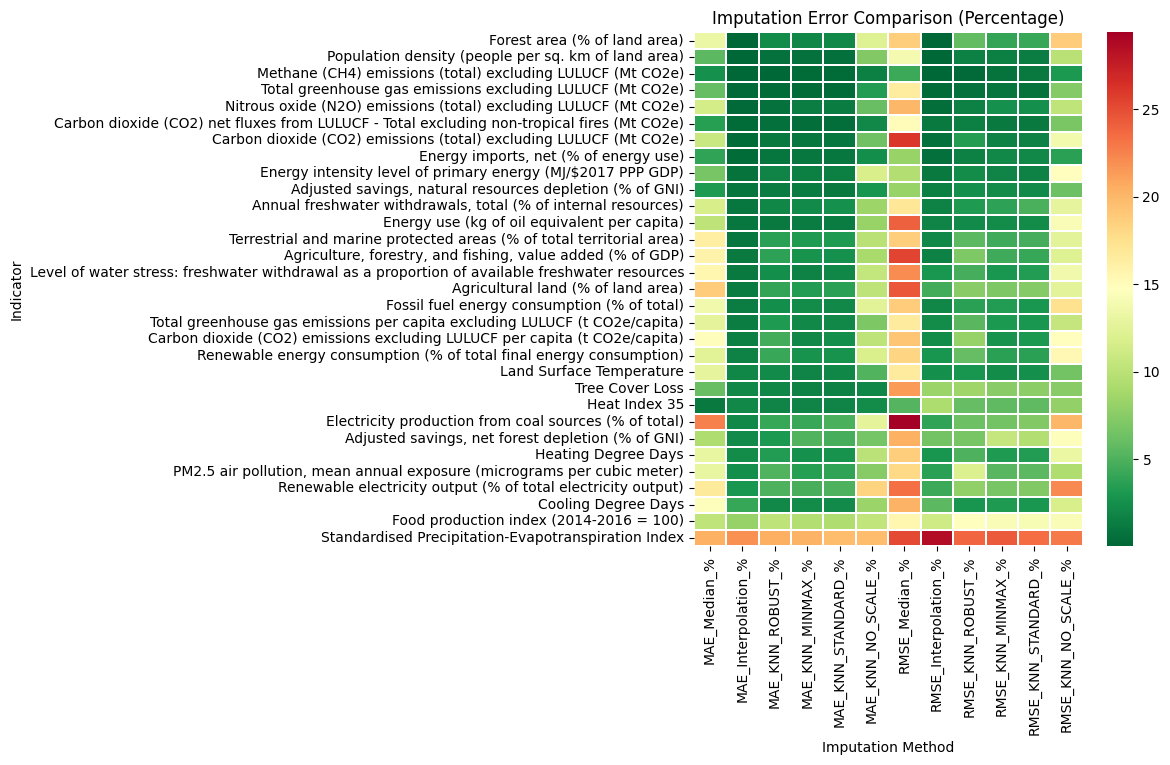

In [41]:
evaluation_env = imputation_evaluation(df_env_europe, missing_fraction=0.1)
heatmap_evaluation(evaluation_env)

## <span style="color:#e0bda8">10.2.  Social Pillar </span>

Index(['Economy', 'Year',
       'Access to clean fuels and technologies for cooking  (% of population)',
       'Access to electricity (% of population)',
       'People using safely managed drinking water services (% of population)',
       'People using safely managed sanitation services (% of population)',
       'Fertility rate, total (births per woman)',
       'Life expectancy at birth, total (years)',
       'Population ages 65 and above (% of total population)',
       'Government expenditure on education, total (% of government expenditure)',
       'School enrollment, primary (% gross)',
       'Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)',
       'Hospital beds (per 1,000 people)',
       'Mortality rate, under-5 (per 1,000 live births)',
       'Prevalence of overweight (% of adults)',
       'Prevalence of undernourishment (% of population)', '

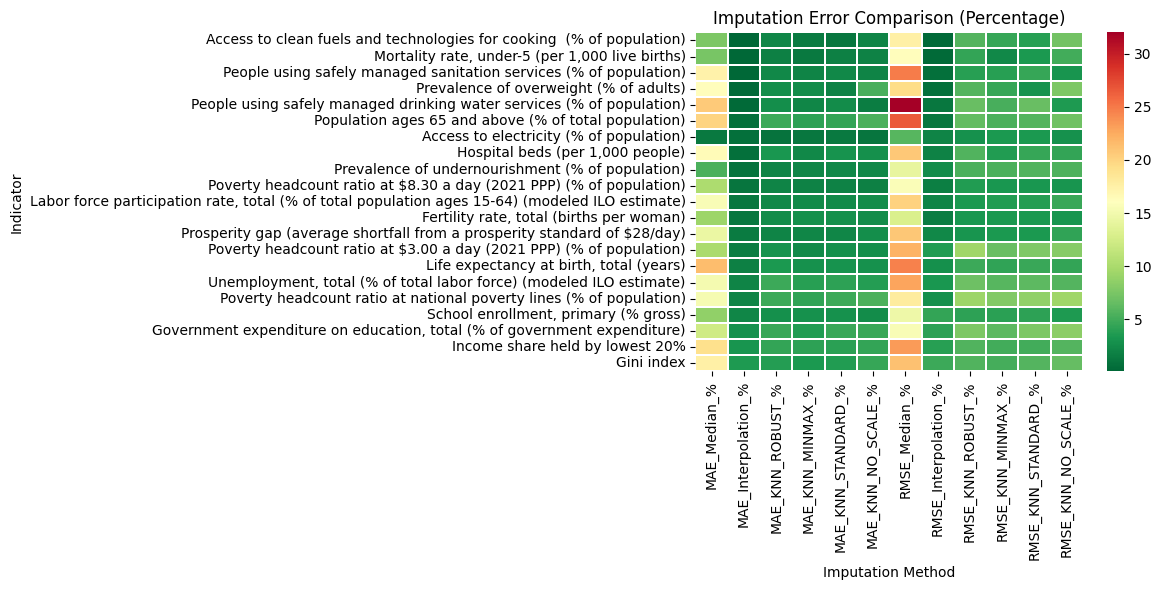

In [42]:
evaluation_soc = imputation_evaluation(df_soc_europe, missing_fraction=0.1)
heatmap_evaluation(evaluation_soc)

## <span style="color:#e0bda8">10.3.  Governance Pillar </span>

Index(['Economy', 'Year', 'GDP (annual % growth)',
       'Individuals using the Internet (% of population)',
       'Proportion of seats held by women in national parliaments (%)',
       'Ratio of female to male labor force participation rate (%) (modeled ILO estimate)',
       'School enrollment, primary and secondary (gross), gender parity index (GPI)',
       'Government Effectiveness: Estimate', 'Regulatory Quality: Estimate',
       'Economic and Social Rights Performance Score',
       'Voice and Accountability: Estimate', 'Patent applications, residents',
       'Research and development expenditure (% of GDP)',
       'Scientific and technical journal articles',
       'Control of Corruption: Estimate', 'Net migration',
       'Political Stability and Absence of Violence/Terrorism: Estimate',
       'Rule of Law: Estimate'],
      dtype='object', name='Indicator name')


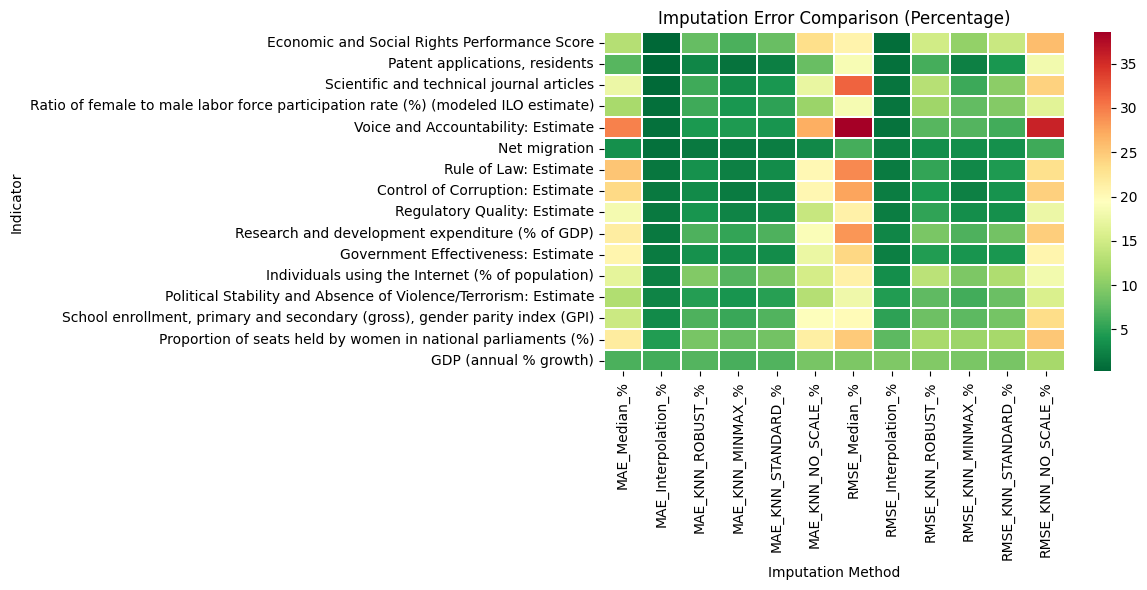

In [43]:
evaluation_gov = imputation_evaluation(df_gov_europe, missing_fraction=0.1)
heatmap_evaluation(evaluation_gov)